# CVXpy (Waskiri-Sat)
$$
\renewcommand{\bm}[1]{\boldsymbol{#1}}
$$

The purpose of the following optimal control policy is:
- Perform Waskiri-Sat (1U CubeSat that uses only magnetorquers as torque actuator) inertial attitude maneuvers.
- Optimize the total power required during each maneuver.
- Perform agile maneuvers, minimizing as much as possible the settling time.

Optimization problem to solve:

$$
	\begin{align*}
		\text{min} \quad &\int_{0}^{t_f}||\bm{m}(t)||_2^2dt+\alpha_m\int_{0}^{t_f}||\dot{\bm{m}}(t)||_2^2dt\\
		\text{s.t.}\quad
		&\dot{\bm{q}}=
		\frac{1}{2}\begin{bmatrix}
			0&-\omega_x&-\omega_y&-\omega_z\\
			\omega_x&0&\omega_z&-\omega_y\\
			\omega_y&-\omega_z&0&\omega_x\\
			\omega_z&\omega_y&-\omega_x&0
		\end{bmatrix}\bm{q}\\
		&\dot{\bm{\omega}}=
		\bm{I}^{-1}(-\bm{\omega}\times\bm{I}\bm{\omega}+(\bm{m}+\bm{m}_{\text{RMM}})\times([B,\text{ECI}]\bm{B}_\text{ECI,Earth}(\bm{r}))\\
		&||\bm{\omega}||_2\leq \omega_{\text{max}}\\
		&||\bm{m}||_\infty\leq m_{\text{max}}\\
		&\bm{q}(0)=\bm{q}_0,\quad\bm{q}(t_f)=\bm{q}_{t_f}\\
		&\bm{w}(0)=\bm{\omega}_0,\quad\bm{\omega}(t_f)=\bm{\omega}_{t_f}
	\end{align*}
$$

In order to optimize computational resources $\bm{h}_{B}=\bm{I}\bm{\omega}$:
$$
	\begin{align*}
		\text{min} \quad &\int_{0}^{t_f}||\bm{m}(t)||_2^2dt+\alpha_m\int_{0}^{t_f}||\dot{\bm{m}}(t)||_2^2dt\\
		\text{s.t.}\quad
		&\dot{\bm{q}}=
		\frac{1}{2}\begin{bmatrix}
			-q_1&-q_2&-q_3\\
			q_0&-q_3&q_2\\
			q_3&q_0&-q_1\\
			-q_2&q_1&q_0
		\end{bmatrix}(\bm{I}^{-1}\bm{h}_B)\\
		&\dot{\bm{h}}_B=
		-(\bm{I}^{-1}\bm{h}_B)\times\bm{h}_B+(\bm{m}+\bm{m}_{\text{RMM}})\times([B,\text{ECI}]\bm{B}_\text{ECI,Earth}(\bm{r}))\\
		&||\bm{I}^{-1}\bm{h}_B||_2\leq \omega_{\text{max}}\\
		&||\bm{m}||_\infty\leq m_{\text{max}}\\
		&\bm{q}(0)=\bm{q}_0,\quad\bm{q}(t_f)=\bm{q}_{t_f}\\
		&\bm{h}_B(0)=\bm{h}_0,\quad\bm{h}(t_f)=\bm{h}_{t_f}
	\end{align*}
$$

Given the scaling matrices and vectors $\bm{S}_x$, $\bm{S}_u$, $\bm{c}_x$, $\bm{c}_u$:

$$\hat{\bm{u}}=\begin{bmatrix}
\bm{a}\\
\bm{\tau}
\end{bmatrix},\quad\hat{\bm{u}}=\bm{S}_u\bm{u}+\bm{c}_u$$

$$\hat{\bm{x}}=\begin{bmatrix}
\bm{r}\\
\bm{v}\\
\bm{q}\\
\bm{\omega}
\end{bmatrix},\quad\hat{\bm{x}}=\bm{S}_x\bm{x}+\bm{c}_x$$

Where scaling matrices and vectors try to limit the optimization variables within $\bm{x}\in[0, 1]^n$, $\bm{u}\in[0, 1]^m$.

First, the original optimization problem is modeled as follows:
$$
\begin{align*}
    \text{min} \quad &J_\lambda(\bm{x},\bm{u},\bm{v}_c,\bm{v}_i)\\
    \text{s.t.}\quad&
        \dot{\hat{\bm{x}}}=
        \bm{f}(\hat{\bm{x}},\hat{\bm{u}},t)\\
    &\bm{g}(\hat{\bm{x}},\hat{\bm{u}},t)\leq \bm{0}\\
    &||\bm{x}-\bar{\bm{x}}||_\infty+||\bm{u}-\bar{\bm{u}}||_\infty\leq \eta\\
    &\hat{\bm{x}}\in\mathcal{X},\quad \hat{\bm{u}}\in\mathcal{U}
\end{align*}
$$
Where $\mathcal{X}$, $\mathcal{U}$ encompass convex restrictions.

Via 1st order Taylor series and matrix algebra:

$$
\begin{equation*}
\hat{\bm{A}}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)=\nabla_{\bm{\hat{x}}}\bm{f}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t),\quad
\hat{\bm{B}}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)=\nabla_{\bm{\hat{u}}}\bm{f}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)
\end{equation*}
$$
$$
\begin{equation*}
\hat{\bm{y}}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)=\bm{f}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)-\nabla_{\bm{\hat{x}}}\bm{f}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)\hat{\bar{\bm{x}}}-\nabla_{\bm{\hat{u}}}\bm{f}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)\hat{\bar{\bm{u}}}
\end{equation*}
$$

$$
\begin{equation*}
\hat{\bm{C}}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)=\nabla_{\bm{\hat{x}}}\bm{g}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t),\quad
\hat{\bm{D}}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)=\nabla_{\bm{\hat{u}}}\bm{g}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)
\end{equation*}
$$
$$
\begin{equation*}
\hat{\bm{z}}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)=\bm{g}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)-\nabla_{\bm{\hat{x}}}\bm{g}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)\hat{\bar{\bm{x}}}-\nabla_{\bm{\hat{u}}}\bm{g}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)\hat{\bar{\bm{u}}}
\end{equation*}
$$

Then, original optimization problem is transformed into:

$$
\begin{align*}
    \text{min} \quad &J_\lambda(\bm{x},\bm{u},\bm{v}_c,\bm{v}_i)\\
    \text{s.t.}\quad&
        \dot{\hat{\bm{x}}}=
        \hat{\bm{A}}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)\hat{\bm{x}}+\hat{\bm{B}}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)\hat{\bm{u}}+\hat{\bm{y}}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)+\bm{v}_c\\
    &\hat{\bm{C}}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)\hat{\bm{x}}+\hat{\bm{D}}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)\hat{\bm{u}}+\hat{\bm{z}}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)\leq \bm{v}_i\\
    &||\bm{x}-\bar{\bm{x}}||_\infty+||\bm{u}-\bar{\bm{u}}||_\infty\leq \eta\\
    &\hat{\bm{x}}\in\mathcal{X},\quad \hat{\bm{u}}\in\mathcal{U}
\end{align*}
$$

Defining:

$$
\begin{equation*}
\bm{A}=\bm{S}_x^{-1}\hat{\bm{A}}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)\bm{S}_x,\quad \bm{B}=\bm{S}_x^{-1}\hat{\bm{B}}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)\bm{S}_u
\end{equation*}
$$
$$
\begin{equation*}
\bm{y}=\bm{S}_x^{-1}\hat{\bm{A}}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)\bm{c}_x+
\bm{S}_x^{-1}\hat{\bm{B}}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)\bm{c}_u+
\bm{S}_x^{-1}\hat{\bm{y}}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)
\end{equation*}
$$

$$
\begin{equation*}
\bm{C}=\hat{\bm{C}}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)\bm{S}_x,\quad \bm{D}=\hat{\bm{D}}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)\bm{S}_u
\end{equation*}
$$
$$
\begin{equation*}
\bm{z}=\hat{\bm{C}}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)\bm{c}_x+
\hat{\bm{D}}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)\bm{c}_u+
\hat{\bm{z}}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)
\end{equation*}
$$

Some matrix algebra leads to the following optimization problem (we omit $\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}}$ dependency for notation simplicity):
$$
\begin{align*}
    \text{min} \quad &J_\lambda(\bm{x},\bm{u},\bm{v}_c,\bm{v}_i)\\
    \text{s.t.}\quad&
        \dot{\bm{x}}=
        \bm{A}(t)\bm{x}+\bm{B}(t)\bm{u}+\bm{y}(t)+\bm{v}_c\\
    &\bm{C}(t)\bm{x}+\bm{D}(t)\bm{u}+\bm{z}(t)\leq \bm{v}_i\\
    &||\bm{x}-\bar{\bm{x}}||_\infty+||\bm{u}-\bar{\bm{u}}||_\infty\leq \eta\\
    &\bm{x}\in\mathcal{X},\quad \bm{u}\in\mathcal{U}
\end{align*}
$$

Let the Linear Time Varying system (LTV):

$$
\begin{equation*}
    \dot{\bm{x}}(t)=\bm{A}(t)\bm{x}(t)+\bm{B}(t)\bm{u}(t)+\bm{y}(t)
\end{equation*}
$$

For a specific $t \in [t_k,t_{k+1}]$, the exact solution for $\bm{x}$ is given by:

$$
\begin{equation*}
    \bm{x}(t_{k+1})=\bm{\Phi}(t_{k+1},t_k)\bm{x}(t_k)+\int_{t_k}^{t_{k+1}}\Phi(t_{k+1},\xi)\bm{B}(\xi)\bm{u}(\xi)d\xi+\int_{t_k}^{t_{k+1}}\Phi(t_{k+1},\xi)\bm{y}(\xi)d\xi
\end{equation*}
$$

State transition matrix $\bm{\Phi}$ properties lead to:
$$
\begin{equation*}
    \bm{x}(t_{k+1})=\bm{\Phi}(t_{k+1},t_k)\bm{x}(t_k)+\bm{\Phi}(t_{k+1},t_k)\int_{t_k}^{t_{k+1}}\bm{\Phi}^{-1}(\xi,t_k)\bm{B}(\xi)\bm{u}(\xi)d\xi+\bm{\Phi}(t_{k+1},t_k)\int_{t_k}^{t_{k+1}}\bm{\Phi}^{-1}(\xi,t_k)\bm{y}(\xi)d\xi
\end{equation*}
$$

Assuming a First Order Hold condition for $\bm{u}(t)$ with $t\in[t_k,t_{k+1})$:
$$
\begin{equation*}
    \bm{u}(t)=\lambda_{k}^{-}(t)\bm{u}(t_k)+\lambda_{k}^{+}(t)\bm{u}(t_{k+1})
\end{equation*}
$$
$$
\begin{equation*}
    \lambda_{k}^{-}(t):=\frac{t_{k+1}-t}{t_{k+1}-t_k},\quad\lambda_{k}^{+}(t):=\frac{t-t_{k}}{t_{k+1}-t_k}
\end{equation*}
$$

Subsequently:

$$
\begin{gather*}
    \bm{x}(t_{k+1})=\bm{\Phi}(t_{k+1},t_k)\bm{x}(t_k)+\bm{\Phi}(t_{k+1},t_k)\int_{t_k}^{t_{k+1}}\bm{\Phi}^{-1}(\xi,t_k)\bm{B}(\xi)\lambda_{k}^{-}(\xi)d\xi\bm{u}(t_k)+\\ \bm{\Phi}(t_{k+1},t_k)\int_{t_k}^{t_{k+1}}\bm{\Phi}^{-1}(\xi,t_k)\bm{B}(\xi)\lambda_{k}^{+}(\xi)d\xi\bm{u}(t_{k+1})+\bm{\Phi}(t_{k+1},t_k)\int_{t_k}^{t_{k+1}}\bm{\Phi}^{-1}(\xi,t_k)\bm{w}(\xi)d\xi
\end{gather*}
$$

For simplicity denoted as:
$$
\begin{equation*}
    \bm{x}_{k+1}=\bm{A}_k\bm{x}_k+\bm{B}_k^{-}\bm{u}_k+\bm{B}_k^{+}\bm{u}_{k+1}+\bm{y}_k
\end{equation*}
$$
Where:
$$
\begin{equation*}
\bm{A}_k=\bm{\Phi}(t_{k+1},t_k)
\end{equation*}
$$
$$
\begin{equation*}
\bm{B}_{k}^{-}=\bm{\Phi}(t_{k+1},t_k)\int_{t_k}^{t_{k+1}}\bm{\Phi}^{-1}(\xi,t_k)\bm{B}(\xi)\lambda_{k}^{-}(\xi)d\xi,\quad 
\bm{B}_{k}^{+}=\bm{\Phi}(t_{k+1},t_k)\int_{t_k}^{t_{k+1}}\bm{\Phi}^{-1}(\xi,t_k)\bm{B}(\xi)\lambda_{k}^{+}(\xi)d\xi
\end{equation*}
$$
$$
\begin{equation*}
\bm{y}_k=\bm{\Phi}(t_{k+1},t_k)\int_{t_k}^{t_{k+1}}\bm{\Phi}^{-1}(\xi,t_k)\bm{y}(\xi)d\xi
\end{equation*}
$$

To compute these discrete matrices at each sampling instant, the following differential equation corresponding to the state transition matrix is solved successively for each discretization step:

$$
\begin{equation*}
\dot{\bm{\Phi}}(t,t_0)=\bm{A}(t)\bm{\Phi}(t,t_0)
\end{equation*}
$$

In this manner, the full SCVx convex optimization problem is formulated:

$$
\begin{align*}
    \text{min} \quad &\mathcal{L}_\lambda(\bm{x},\bm{u},\bm{v}_c,\bm{v}_i)\\
    \text{s.t.}\quad&
        \bm{x}_{k+1}=\bm{A}_k\bm{x}_k+\bm{B}_k^{-}\bm{u}_k+\bm{B}_k^{+}\bm{u}_{k+1}+\bm{y}_k\\
    &\bm{C}_{k}\bm{x}_{k}+\bm{D}_{k}\bm{u}_{k}+\bm{z}_{k}\leq \bm{v}_{i_k}\\
    &||\bm{x}_{k}-\bar{\bm{x}}_{k}||_1+||\bm{u}_{k}-\bar{\bm{u}}_{k}||_1\leq \eta\\
    &\bm{x}_k\in\mathcal{X}_k,\quad \bm{u}_k\in\mathcal{U}_k
\end{align*}
$$

This example denotes for instance (not always):
- $\hat{\bm{x}}$ as `hx`(no scaled).
- $\bm{x}$ as `x` (scaled)
- $\bm{x}_k$ as `x[:,k:k+1]` (discrete scaled)
- $\bar{\bm{x}}_k$ as `ox[:,k:k+1]` (discrete scaled old, last generated trajectory)

Libraries:

In [12]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R, Slerp
import time
import ecos
import math

import sympy as sp
from sympy.physics.vector import ReferenceFrame

import re

Don't execute if you have already the file 'f_A_B_y_functions.py'

In [13]:
mx, my, mz = sp.symbols('mx my mz')

t = sp.symbols('t')
t0 = sp.symbols('t0')

q0, q1, q2, q3 = sp.symbols('q0 q1 q2 q3')
hbx, hby, hbz = sp.symbols('hbx hby hbz')


invIxx, invIyy, invIzz = sp.symbols('invIxx invIyy invIzz')
invIxy, invIxz, invIyz = sp.symbols('invIxy invIxz invIyz')

n_cubesat, Omega, inc, B0 = sp.symbols('n_cubesat Omega inc B0')

# Rigid body kinematics
BN = sp.Matrix([
    [q0**2 + q1**2 - q2**2 - q3**2, 2*(q1*q2 + q0*q3), 
    2*(-q0*q2 + q1*q3)], [2*(q1*q2 - q0*q3), q0**2 - q1**2 + q2**2 - q3**2, 
    2*(q0*q1 + q2*q3)], [2*(q0*q2 + q1*q3), 2*(-q0*q1 + q2*q3), 
    q0**2 - q1**2 - q2**2 + q3**2]
])

invI = sp.Matrix([
    [invIxx, invIxy, invIxz],
    [invIxy, invIyy, invIyz],
    [invIxz, invIyz, invIzz]
])

O_B = sp.Matrix([
    -2*sp.sin(inc)*sp.cos(n_cubesat*(t+t0)),
    -sp.sin(inc)*sp.sin(n_cubesat*(t+t0)),
    sp.cos(inc)
]) * B0

Nframe = ReferenceFrame('Nframe')
Oframe = Nframe.orientnew('Oframe', 'Body', [Omega, inc, n_cubesat*(t+t0)], 'ZXZ')

ON = Oframe.dcm(Nframe)

BO = BN * ON.T

Don't execute if you have already the file 'f_A_B_y_functions.py'

In [14]:
hb_sympy = sp.Matrix([hbx, hby, hbz])
m_sympy = sp.Matrix([mx, my, mz])

f_ridig_body = (- (invI@hb_sympy).cross(hb_sympy) + m_sympy.cross(BO@O_B))

f_quaternion = 0.5 *sp.Matrix([[-q1,-q2,-q3],[q0,-q3,q2],[q3,q0,-q1],[-q2,q1,q0]])@(invI@hb_sympy)

f1 = f_quaternion[0]
f2 = f_quaternion[1]
f3 = f_quaternion[2]
f4 = f_quaternion[3]
f5 = f_ridig_body[0]
f6 = f_ridig_body[1]
f7 = f_ridig_body[2]

f_orig_opt_prob=[f1,f2,f3,f4,f5,f6,f7]

g_orig_opt_prob = []

x_states = [q0,q1,q2,q3,hbx,hby,hbz]
u_input = [mx,my,mz]

states_size = len(x_states)
inputs_size = len(u_input)
non_convex_inequalities_size = len(g_orig_opt_prob)

In [15]:
state_parameters_string = [
    "q0",
    "q1",
    "q2",
    "q3",
    "hbx",
    "hby",
    "hbz"
]

control_parameters_string = [
    "mx",
    "my",
    "mz"
]

time_string = [
    "t"
]

dynamic_parameters_string = [
    "invIxx",
    "invIyy",
    "invIzz",
    "invIxy",
    "invIxz",
    "invIyz",
    "n_cubesat",
    "Omega",
    "inc",
    "B0",
    "t0"
]

Don't execute if you have already the file 'f_g_A_B_y_C_D_z_functions.py'

In [16]:
def replace_variables_in_string(f_str,
                                state_parameters_string,
                                control_parameters_string,
                                dynamic_parameters_string):

    # Replace states
    for i, var in enumerate(state_parameters_string):
        f_str = re.sub(rf"\b{var}\b", f"hx[{i},0]", f_str)

    # Replace inputs
    for i, var in enumerate(control_parameters_string):
        f_str = re.sub(rf"\b{var}\b", f"hu[{i},0]", f_str)

    # Replace problem parameters
    for i, var in enumerate(dynamic_parameters_string):
        f_str = re.sub(rf"\b{var}\b", f"dyn_par[{i}]", f_str)

    return f_str

def matrix_to_numpy_string(matrix, state_params, control_params, dynamic_params):
    """
    Converts a sympy symbolic matrix into a string representing a numpy.array,
    with optional variable replacement using replace_variables_in_string.

    Args:
        matrix: sympy.Matrix of any dimension.
        state_params, control_params, dynamic_params: strings for variable replacement.

    Returns:
        A string representing a numpy.array ready to be evaluated in Python.
    """

    n_rows, *rest = np.shape(matrix)
    n_cols = rest[0] if rest else 1
    
    matrix = sp.Matrix(n_rows, n_cols, lambda i, j: matrix[i*n_cols + j])

    array_str = "np.array([["

    for i in range(0,n_rows):
        for j in range(0,n_cols):
            array_str += sp.pycode(matrix[i, j])
            if j < n_cols - 1:
                array_str += ","
        if i < n_rows - 1:
            array_str += "],["
        else:
            array_str += "]])"

    # Apply variable replacement using your custom function
    array_str = replace_variables_in_string(array_str,
                                            state_params,
                                            control_params,
                                            dynamic_params)
    return array_str

#Automated Python script creation

#f
string_f_SCVx=matrix_to_numpy_string(f_orig_opt_prob,
                                                    state_parameters_string,
                                                    control_parameters_string,
                                                    dynamic_parameters_string)
print("\nf_SCVx:\n")
print(string_f_SCVx)

#A, B, y
A_symbolic = sp.Matrix(f_orig_opt_prob).jacobian(x_states) #Sympy Jacobian (Linearization via Taylor series)

string_A_SCVx =string_A_SCVx=matrix_to_numpy_string(A_symbolic,
                                                    state_parameters_string,
                                                    control_parameters_string,
                                                    dynamic_parameters_string)
print("\nA_no_discrete_no_scaled:\n")
print(string_A_SCVx)

B_symbolic = sp.Matrix(f_orig_opt_prob).jacobian(u_input) #Sympy Jacobian (Linearization via Taylor series)

string_B_SCVx =string_B_SCVx=matrix_to_numpy_string(B_symbolic,
                                                    state_parameters_string,
                                                    control_parameters_string,
                                                    dynamic_parameters_string)
print("\nB_no_discrete_no_scaled:\n")
print(string_B_SCVx)

y_symbolic = f_orig_opt_prob-A_symbolic@np.transpose(x_states)-B_symbolic@np.transpose(u_input) #Sympy Jacobian (Linearization via Taylor series)

string_y_SCVx =string_y_SCVx=matrix_to_numpy_string(y_symbolic,
                                                    state_parameters_string,
                                                    control_parameters_string,
                                                    dynamic_parameters_string)
print("\ny_no_discrete_no_scaled:\n")
print(string_y_SCVx)

string_g_SCVx = "0"
string_C_SCVx = "0"
string_D_SCVx = "0"
string_z_SCVx = "0"

if(non_convex_inequalities_size>0):
    #g
    string_g_SCVx=matrix_to_numpy_string(g_orig_opt_prob,
                                                    state_parameters_string,
                                                    control_parameters_string,
                                                    dynamic_parameters_string)
    print("\ng_SCVx:\n")
    print(string_g_SCVx)
    #C, D, z
    C_symbolic = sp.Matrix(g_orig_opt_prob).jacobian(x_states) #Sympy Jacobian (Linearization via Taylor series)

    string_C_SCVx = matrix_to_numpy_string(C_symbolic,
                                            state_parameters_string,
                                            control_parameters_string,
                                            dynamic_parameters_string)
    print("\nC_no_discrete_no_scaled:\n")
    print(string_C_SCVx)

    D_symbolic = sp.Matrix(g_orig_opt_prob).jacobian(u_input) #Sympy Jacobian (Linearization via Taylor series)

    string_D_SCVx = matrix_to_numpy_string(D_symbolic,
                                            state_parameters_string,
                                            control_parameters_string,
                                            dynamic_parameters_string)
    print("\nD_no_discrete_no_scaled:\n")
    print(string_D_SCVx)

    z_symbolic = g_orig_opt_prob-C_symbolic@np.transpose(x_states)-D_symbolic@np.transpose(u_input) #Sympy Jacobian (Linearization via Taylor series)

    string_z_SCVx = matrix_to_numpy_string(z_symbolic,
                                            state_parameters_string,
                                            control_parameters_string,
                                            dynamic_parameters_string)
    print("\nz_no_discrete_no_scaled:\n")
    print(string_z_SCVx)

#Write f, g, A, y, C, D, z functions inside f_g_A_B_y_C_D_z_functions.py

filename = "f_g_A_B_y_C_D_z_functions.py"

file_content = f"""
import numpy as np
import math

def f_SCVx(hx, hu, t, dyn_par):
    return {string_f_SCVx}

def g_SCVx(hx, hu, t, dyn_par):
    return {string_g_SCVx}

def A_no_discrete_no_scaled_SCVx(hx, hu, t, dyn_par):
    return {string_A_SCVx}

def B_no_discrete_no_scaled_SCVx(hx, hu, t, dyn_par):
    return {string_B_SCVx}

def y_no_discrete_no_scaled_SCVx(hx, hu, t, dyn_par):
    return {string_y_SCVx}

def C_no_discrete_no_scaled_SCVx(hx, hu, t, dyn_par):
    return {string_C_SCVx}

def D_no_discrete_no_scaled_SCVx(hx, hu, t, dyn_par):
    return {string_D_SCVx}

def z_no_discrete_no_scaled_SCVx(hx, hu, t, dyn_par):
    return {string_z_SCVx}
"""
with open(filename, "w", encoding="utf-8") as f:
    f.write(file_content)
print("\nSymbolic algebra functions implemented!")


f_SCVx:

np.array([[-0.5*hx[1,0]*(hx[4,0]*dyn_par[0] + hx[5,0]*dyn_par[3] + hx[6,0]*dyn_par[4]) - 0.5*hx[2,0]*(hx[4,0]*dyn_par[3] + hx[5,0]*dyn_par[1] + hx[6,0]*dyn_par[5]) - 0.5*hx[3,0]*(hx[4,0]*dyn_par[4] + hx[5,0]*dyn_par[5] + hx[6,0]*dyn_par[2])],[0.5*hx[0,0]*(hx[4,0]*dyn_par[0] + hx[5,0]*dyn_par[3] + hx[6,0]*dyn_par[4]) + 0.5*hx[2,0]*(hx[4,0]*dyn_par[4] + hx[5,0]*dyn_par[5] + hx[6,0]*dyn_par[2]) - 0.5*hx[3,0]*(hx[4,0]*dyn_par[3] + hx[5,0]*dyn_par[1] + hx[6,0]*dyn_par[5])],[0.5*hx[0,0]*(hx[4,0]*dyn_par[3] + hx[5,0]*dyn_par[1] + hx[6,0]*dyn_par[5]) - 0.5*hx[1,0]*(hx[4,0]*dyn_par[4] + hx[5,0]*dyn_par[5] + hx[6,0]*dyn_par[2]) + 0.5*hx[3,0]*(hx[4,0]*dyn_par[0] + hx[5,0]*dyn_par[3] + hx[6,0]*dyn_par[4])],[0.5*hx[0,0]*(hx[4,0]*dyn_par[4] + hx[5,0]*dyn_par[5] + hx[6,0]*dyn_par[2]) + 0.5*hx[1,0]*(hx[4,0]*dyn_par[3] + hx[5,0]*dyn_par[1] + hx[6,0]*dyn_par[5]) - 0.5*hx[2,0]*(hx[4,0]*dyn_par[0] + hx[5,0]*dyn_par[3] + hx[6,0]*dyn_par[4])],[hx[5,0]*(hx[4,0]*dyn_par[4] + hx[5,0]*dyn_par[5] + hx[

**Execute!**

In [17]:
from f_g_A_B_y_C_D_z_functions import *

In [18]:
T = 51-1 # 101-1 means 101 discretization points
tf = 100.0
tau_double = tf/(T)
size_N=10 #discretization accuracy
print("Step: ",tau_double," [s]")

t0_double = 2000 #initial time (basic orbit propagator)

#start_quat=np.array([[0],[(1-0.99**2)**0.5],[0.99],[0]])
start_quat=np.array([[0],[1],[0],[0]])
#end_quat=np.array([[0.5],[0.4],[0],[(1-0.5**2-0.4**2)**0.5]])
end_quat=np.array([[0],[0],[1],[0]])

start_w_xyz=np.array([[-0.2*np.pi/180],[0.2*np.pi/180],[0.4*np.pi/180]])
end_w_xyz=np.array([[0.0],[0.0],[0.0]])

Jsat_double = np.array([[0.0022,0.00002,0.00002],[0.00002,0.0021,0.00002],[0.00002,0.00002,0.0019]]) #Kg m^2
invJsat_double = np.linalg.inv(Jsat_double)

start_hb=Jsat_double@start_w_xyz
end_hb=Jsat_double@end_w_xyz

start_pos_double=np.block([[start_quat],[start_hb]])
end_pos_double=np.block([[end_quat],[end_hb]])

start_input_double = np.array([[0],[0],[0]])
end_input_double = np.array([[0],[0],[0]])

invJ1_double = invJsat_double[0,0]
invJ2_double = invJsat_double[1,1]
invJ3_double = invJsat_double[2,2]

invJxy_double=invJsat_double[0,1]
invJxz_double=invJsat_double[0,2]
invJyz_double=invJsat_double[1,2]

m_max_double = 0.2 #A m^2
omega_max_double = 10.0*np.pi/180 #rad/s

#Circular SSO assumed

mu_earth = 3.986004418e14        # [m^3/s^2] Earth gravitational parameter
R_E = 6378e3               # [m] Earth radius
h_cubesat = 500e3                  # [m] altitude
mu0_over_4pi = 1e-7       # magnetic constant factor
m_E = 7.94e22             # [A·m^2] Earth magnetic dipole moment
a_cubesat = R_E + h_cubesat

n_cubesat_double = np.sqrt(mu_earth / a_cubesat**3)    # rad/s
Omega_double = 45*math.pi/180 # Right ascending node
inc_double = 97.6*math.pi/180 # Satellite inclination SSO
B0_double = mu0_over_4pi * m_E / a_cubesat**3   # Tesla

#Guidance parameters (COGU parameters)

COGU_max_iter = 25

alpha_m_double = 1

rho0=0.0
rho1=0.1
rho2=0.7
etta0=0.000001
etta1=10
beta_sh=2
beta_gr=2

lamb_double=10000
etta_double_init=1

e_tol=0.005
epsilon_stop_norm=0.00001

#scaling matrices and vectors
S_u_scaling_double=np.array([[2*(0.5*m_max_double),0,0],
                      [0,2*(0.5*m_max_double),0],
                      [0,0,2*(0.5*m_max_double)]])

c_u_scaling_double=np.array([[-(0.5*m_max_double)],
                      [-(0.5*m_max_double)],
                      [-(0.5*m_max_double)]])

S_x_scaling_double=np.array([
                      [2*1,0,0,0,0,0,0],
                      [0,2*1,0,0,0,0,0],
                      [0,0,2*1,0,0,0,0],
                      [0,0,0,2*1,0,0,0],
                      [0,0,0,0,2*(0.5*Jsat_double[0,0]*omega_max_double),0,0],
                      [0,0,0,0,0,2*(0.5*Jsat_double[1,1]*omega_max_double),0],
                      [0,0,0,0,0,0,2*(0.5*Jsat_double[2,2]*omega_max_double)]])

c_x_scaling_double=np.array([
                      [-1],
                      [-1],
                      [-1],
                      [-1],
                      [-(0.5*Jsat_double[0,0]*omega_max_double)],
                      [-(0.5*Jsat_double[1,1]*omega_max_double)],
                      [-(0.5*Jsat_double[2,2]*omega_max_double)]])

Step:  2.0  [s]


In [19]:
dynamic_parameters_double = [
    invJ1_double,
    invJ2_double,
    invJ3_double,
    invJxy_double,
    invJxz_double,
    invJyz_double,
    n_cubesat_double,
    Omega_double,
    inc_double,
    B0_double,
    t0_double
]

Warm starting:

In [20]:
def slerp(q1, q2, num_samples):
    dot = np.dot(q1, q2)
    if dot < 0.0:
        q2 = -q2
        dot = -dot
    dot = np.clip(dot, -1.0, 1.0)
    theta_0 = np.arccos(dot)

    if np.abs(theta_0) < 1e-6:
        return np.linspace(q1, q2, num_samples)

    sin_theta_0 = np.sin(theta_0)

    quaternions = []
    for i in range(num_samples):
        t = i / (num_samples - 1)
        theta = theta_0 * t
        sin_theta = np.sin(theta)
        s0 = np.cos(theta) - dot * sin_theta / sin_theta_0
        s1 = sin_theta / sin_theta_0
        quaternions.append(s0 * q1 + s1 * q2)

    return np.array(quaternions)

def compute_angular_velocity(quaternions, dt):

    rotations = R.from_quat(quaternions)
    angular_velocities = [[0,0,0]]

    for i in range(len(rotations) - 1):
        delta_rot = rotations[i + 1] * rotations[i].inv()
        log_rot = delta_rot.as_rotvec() / dt
        angular_velocities.append(log_rot)

    return np.array(angular_velocities)

# Initial trajectory (without scaling)

ohx_quat = slerp(start_pos_double[0:4,0], end_pos_double[0:4,0],T+1).T
ohx_hb = Jsat_double@compute_angular_velocity(ohx_quat.T, tau_double).T

ohx_init=np.zeros((states_size,T+1))
ohx_init[0:4,:]=ohx_quat
ohx_init[4:7,:]=ohx_hb

ohu_init=np.zeros((inputs_size,T+1))

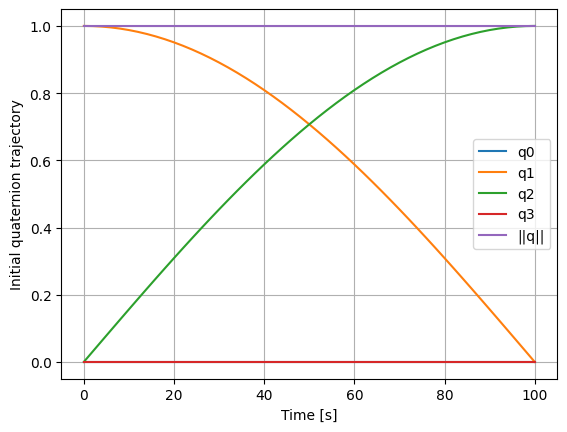

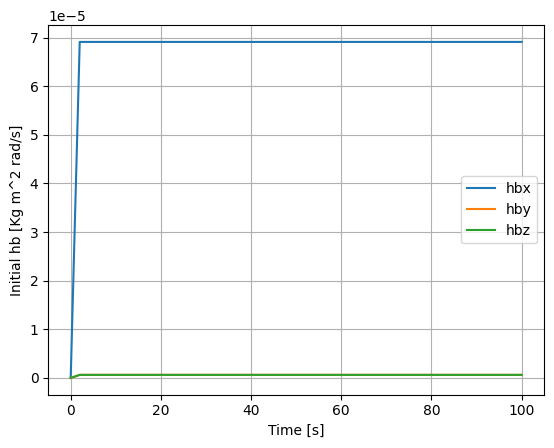

In [21]:
hu_value=np.copy(ohu_init)
hx_value=np.copy(ohx_init)

plt.figure(1)
plt.plot(np.linspace(0, tf, T+1), hx_value[0,:], label='q0')
plt.plot(np.linspace(0, tf, T+1), hx_value[1,:], label='q1')
plt.plot(np.linspace(0, tf, T+1), hx_value[2,:], label='q2')
plt.plot(np.linspace(0, tf, T+1), hx_value[3,:], label='q3')
plt.plot(np.linspace(0, tf, T+1), np.linalg.norm(hx_value[0:4,:],axis=0), label='||q||')
plt.ylabel('Initial quaternion trajectory')
plt.xlabel('Time [s]')
plt.gca().tick_params(labelsize=10)
plt.legend()
plt.grid(True)

plt.figure(2)
plt.plot(np.linspace(0, tf, T+1), hx_value[4,:], label='hbx')
plt.plot(np.linspace(0, tf, T+1), hx_value[5,:], label='hby')
plt.plot(np.linspace(0, tf, T+1), hx_value[6,:], label='hbz')
plt.ylabel('Initial hb [Kg m^2 rad/s]')
plt.xlabel('Time [s]')
plt.gca().tick_params(labelsize=10)
plt.legend()
plt.grid(True)

CVXpy Optimization problem (DPP compliant for cvxpygen)

In [22]:
x = cp.Variable((states_size, T + 1), name='x')
u = cp.Variable((inputs_size, T + 1), name='u')
vc = cp.Variable((states_size, T), name='vc')
if non_convex_inequalities_size>0:
    vi = cp.Variable((non_convex_inequalities_size, T+1), name='vi')

A_discrete = cp.Parameter((states_size,states_size*T), name='A_discrete')
B_discrete_l = cp.Parameter((states_size,inputs_size*T), name='B_discrete_l')
B_discrete_r = cp.Parameter((states_size,inputs_size*T), name='B_discrete_r')
y_discrete = cp.Parameter((states_size,1*T), name='y_discrete')

if non_convex_inequalities_size>0:
    C_discrete = cp.Parameter((non_convex_inequalities_size,states_size*(T+1)), name='C_discrete')
    D_discrete = cp.Parameter((non_convex_inequalities_size,inputs_size*(T+1)), name='D_discrete')
    z_discrete = cp.Parameter((non_convex_inequalities_size,1*(T+1)), name='z_discrete')

tau = cp.Parameter(name='tau')
sqrt_tau = cp.Parameter(name='sqrt_tau')
sqrt_alpha_m_sqrt_tau = cp.Parameter(name='sqrt_alpha_m_sqrt_tau')

start_pos = cp.Parameter((states_size,1), name='start_pos')
end_pos = cp.Parameter((states_size,1), name='end_pos')

start_input = cp.Parameter((inputs_size,1), name='start_input')
end_input = cp.Parameter((inputs_size,1), name='end_input')

ox_cvxpy = cp.Parameter((states_size,T + 1), name='ox_cvxpy')
ou_cvxpy = cp.Parameter((inputs_size,T + 1), name='ou_cvxpy')

S_x_scaling = cp.Parameter((states_size,states_size), name='S_x_scaling')
S_u_scaling = cp.Parameter((inputs_size,inputs_size), name='S_u_scaling')

c_x_scaling = cp.Parameter((states_size,1), name='c_x_scaling')
c_u_scaling = cp.Parameter((inputs_size,1), name='c_u_scaling')

inv_Jb_S_b_scaling = cp.Parameter((3,3), name='inv_Jb_S_b_scaling')
inv_Jb_c_b_scaling = cp.Parameter((3,1), name='inv_Jb_c_b_scaling')

lamb = cp.Parameter(name='lamb')
tau_lamb = cp.Parameter(name='tau_lamb')
etta = cp.Parameter(name='etta')

omega_max = cp.Parameter(name='omega_max')

m_max = cp.Parameter(name='m_max')

constraints = [
    x[:, 0] == start_pos[:,0],
    x[:, T] == end_pos[:,0],
    #u[:, 0] == start_input[:,0],
    #u[:, T] == end_input[:,0]
]

cost = 0

for k in range(0, T):
    cost += (1/3) * (cp.sum_squares(sqrt_tau*u[0:3,k:k+1]) + cp.sum_squares(sqrt_tau*u[0:3,k+1:k+2]) + cp.sum_squares(sqrt_tau*(u[0:3,k:k+1] - u[0:3,k+1:k+2])))
    
for k in range(1, T+1):
    cost += cp.sum_squares(sqrt_alpha_m_sqrt_tau*(u[0:3,k:k+1]-u[0:3,k-1:k]))
for k in range(0, T):
    cost += cp.norm(tau_lamb*vc[0:states_size, k:k+1],1)

if non_convex_inequalities_size>0:
    for k in range(0, T+1):
        cost += cp.norm(tau_lamb*vi[0:non_convex_inequalities_size, k:k+1],1)

for k in range(0, T): # from 0 to T-1
    constraints += [x[0:states_size, k+1:k+2] == A_discrete[0:states_size,states_size*k:states_size*(k+1)] @ x[0:states_size, k:k+1] + B_discrete_l[0:states_size,inputs_size*k:inputs_size*(k+1)] @ u[0:inputs_size, k:k+1]+B_discrete_r[0:states_size,inputs_size*k:inputs_size*(k+1)] @ u[0:inputs_size, k+1:k+2]+y_discrete[0:states_size, k:k+1]+vc[0:states_size, k:k+1]]

if non_convex_inequalities_size>0:
    for k in range(0, T+1): # from 0 to T
        constraints += [C_discrete[0:non_convex_inequalities_size,states_size*k:states_size*(k+1)] @ x[0:states_size, k:k+1] + D_discrete[0:non_convex_inequalities_size,inputs_size*k:inputs_size*(k+1)] @ u[0:inputs_size, k:k+1]+z_discrete[0:non_convex_inequalities_size, k:k+1]<=vi[0:non_convex_inequalities_size, k:k+1]]

for k in range(0, T+1): # from 0 to T
    constraints += [cp.norm(x[0:states_size, k:k+1]-ox_cvxpy[0:states_size,k:k+1],'inf')+cp.norm(u[0:inputs_size, k:k+1]-ou_cvxpy[0:inputs_size,k:k+1],'inf')<=etta]

# Convex constraints
for k in range(0, T+1): # from 0 to T
    constraints += [cp.norm(inv_Jb_S_b_scaling@x[4:7,k:k+1]+inv_Jb_c_b_scaling, 2)<=omega_max]
for k in range(0, T+1): # from 0 to T-1
    constraints += [cp.norm(S_u_scaling[0:3,0:3]@u[0:3,k:k+1]+c_u_scaling[0:3,0:1], 'inf')<=m_max]

objective = cp.Minimize(cost)
problem = cp.Problem(objective, constraints)

In [23]:
print("Is DPP? ", problem.is_dcp(dpp=True))

Is DPP?  True


In [24]:
aux_A_discrete = np.zeros((states_size,states_size*T))
aux_B_discrete_l = np.zeros((states_size,inputs_size*T))
aux_B_discrete_r = np.zeros((states_size,inputs_size*T))
aux_y_discrete = np.zeros((states_size,1*T))

if non_convex_inequalities_size>0:
    aux_C_discrete = np.zeros((non_convex_inequalities_size,states_size*(T+1)))
    aux_D_discrete = np.zeros((non_convex_inequalities_size,inputs_size*(T+1)))
    aux_z_discrete = np.zeros((non_convex_inequalities_size,1*(T+1)))

In [25]:
def SCVx_scaling_x(x_no_scaled,inv_S_x_scaling_double,c_x_scaling_double):
    x_scaled = inv_S_x_scaling_double@(x_no_scaled-c_x_scaling_double)
    return x_scaled
    
def SCVx_scaling_u(u_no_scaled,inv_S_u_scaling_double,c_u_scaling_double):
    u_scaled = inv_S_u_scaling_double@(u_no_scaled-c_u_scaling_double)
    return u_scaled

def SCVx_inv_scaling_x(x_scaled,S_x_scaling_double,c_x_scaling_double):
    x_inv_scaling = S_x_scaling_double@x_scaled+c_x_scaling_double
    return x_inv_scaling
    
def SCVx_inv_scaling_u(u_scaled,S_u_scaling_double,c_u_scaling_double):
    u_inv_scaling = S_u_scaling_double@u_scaled+c_u_scaling_double
    return u_inv_scaling


def A_no_discrete_scaled_SCVx(A_no_discrete_no_scaled, inv_S_x_scaling_double,S_x_scaling_double):

    A_numeric = inv_S_x_scaling_double@A_no_discrete_no_scaled@S_x_scaling_double

    return A_numeric

def B_no_discrete_scaled_SCVx(B_no_discrete_no_scaled, inv_S_x_scaling_double, S_u_scaling_double):

    B_numeric = inv_S_x_scaling_double@B_no_discrete_no_scaled@S_u_scaling_double

    return B_numeric

def y_no_discrete_scaled_SCVx(A_no_discrete_no_scaled,
                              B_no_discrete_no_scaled,
                              y_no_discrete_no_scaled,
                              inv_S_x_scaling_double, c_x_scaling_double, c_u_scaling_double):

    y_numeric = inv_S_x_scaling_double@A_no_discrete_no_scaled@c_x_scaling_double
    y_numeric = y_numeric+inv_S_x_scaling_double@B_no_discrete_no_scaled@c_u_scaling_double
    y_numeric = y_numeric+inv_S_x_scaling_double@y_no_discrete_no_scaled

    return y_numeric
    
import numpy as np

def A_Bl_Br_y_discrete_scaled(
        ohx, ohu, t0, dynamic_parameters_double, tau_double,
        S_x_scaling_double, inv_S_x_scaling_double, c_x_scaling_double,
        S_u_scaling_double, inv_S_u_scaling_double, c_u_scaling_double,
        size_N):

    n = len(ohx)
    m = len(ohu)

    # Condiciones iniciales para la integración en el intervalo [t0, t0 + tau]
    Phi = np.eye(n)
    Gm  = np.zeros((n, m))   # B_k^-
    Gp  = np.zeros((n, m))   # B_k^+
    z   = np.zeros((n, 1))

    dt = tau_double / (size_N - 1)
    t  = t0
    tf = t0 + tau_double

    # Función auxiliar para Lambdas de FOH (Interpolación lineal)
    # lam_m(t0) = 1, lam_m(tf) = 0
    # lam_p(t0) = 0, lam_p(tf) = 1
    def lambdas(ti):
        lam_m = (tf - ti) / tau_double
        lam_p = (ti - t0) / tau_double
        return lam_m, lam_p

    def get_scaled_dynamics(t_eval):
        # 1. Obtener matrices continuas no escaladas (LTV: dependen de t)
        A_no = A_no_discrete_no_scaled_SCVx(ohx, ohu, t_eval, dynamic_parameters_double)
        B_no = B_no_discrete_no_scaled_SCVx(ohx, ohu, t_eval, dynamic_parameters_double)
        y_no = y_no_discrete_no_scaled_SCVx(ohx, ohu, t_eval, dynamic_parameters_double)

        # 2. Aplicar escalado
        A = A_no_discrete_scaled_SCVx(A_no, inv_S_x_scaling_double, S_x_scaling_double)
        B = B_no_discrete_scaled_SCVx(B_no, inv_S_x_scaling_double, S_u_scaling_double)
        y = y_no_discrete_scaled_SCVx(A_no, B_no, y_no, inv_S_x_scaling_double, c_x_scaling_double, c_u_scaling_double)
        return A, B, y

    for i in range(size_N - 1):
        # ===== k1 (Inicio del sub-paso) =====
        lam_m1, lam_p1 = lambdas(t)
        A1, B1, y1 = get_scaled_dynamics(t)

        k1_Phi = A1 @ Phi
        k1_Gm  = A1 @ Gm + B1 * lam_m1
        k1_Gp  = A1 @ Gp + B1 * lam_p1
        k1_z   = A1 @ z  + y1

        # ===== k2 (Punto medio) =====
        t2 = t + 0.5 * dt
        lam_m2, lam_p2 = lambdas(t2)
        A2, B2, y2 = get_scaled_dynamics(t2)

        Phi2 = Phi + 0.5 * dt * k1_Phi
        Gm2  = Gm  + 0.5 * dt * k1_Gm
        Gp2  = Gp  + 0.5 * dt * k1_Gp
        z2   = z   + 0.5 * dt * k1_z

        k2_Phi = A2 @ Phi2
        k2_Gm  = A2 @ Gm2 + B2 * lam_m2
        k2_Gp  = A2 @ Gp2 + B2 * lam_p2
        k2_z   = A2 @ z2  + y2

        # ===== k3 (Punto medio con k2) =====
        # En LTV, A, B y y son los mismos que en k2 porque t es el mismo
        Phi3 = Phi + 0.5 * dt * k2_Phi
        Gm3  = Gm  + 0.5 * dt * k2_Gm
        Gp3  = Gp  + 0.5 * dt * k2_Gp
        z3   = z   + 0.5 * dt * k2_z

        k3_Phi = A2 @ Phi3
        k3_Gm  = A2 @ Gm3 + B2 * lam_m2
        k3_Gp  = A2 @ Gp3 + B2 * lam_p2
        k3_z   = A2 @ z3  + y2

        # ===== k4 (Final del sub-paso) =====
        t4 = t + dt
        lam_m4, lam_p4 = lambdas(t4)
        A4, B4, y4 = get_scaled_dynamics(t4)

        Phi4 = Phi + dt * k3_Phi
        Gm4  = Gm  + dt * k3_Gm
        Gp4  = Gp  + dt * k3_Gp
        z4   = z   + dt * k3_z

        k4_Phi = A4 @ Phi4
        k4_Gm  = A4 @ Gm4 + B4 * lam_m4
        k4_Gp  = A4 @ Gp4 + B4 * lam_p4
        k4_z   = A4 @ z4  + y4

        # ===== RK4 Update =====
        Phi += (dt / 6) * (k1_Phi + 2*k2_Phi + 2*k3_Phi + k4_Phi)
        Gm  += (dt / 6) * (k1_Gm  + 2*k2_Gm  + 2*k3_Gm  + k4_Gm)
        Gp  += (dt / 6) * (k1_Gp  + 2*k2_Gp  + 2*k3_Gp  + k4_Gp)
        z   += (dt / 6) * (k1_z   + 2*k2_z   + 2*k3_z   + k4_z)

        t += dt

    # Resultados finales
    # Dado que integramos la forma completa de la ODE:
    # dot_G = A*G + B*lambda, el valor final ya es la matriz discreta.
    return Phi, Gm, Gp, z

def C_no_discrete_scaled_SCVx(C_no_discrete_no_scaled, S_x_scaling_double):

    C_numeric = C_no_discrete_no_scaled@S_x_scaling_double

    return C_numeric

def D_no_discrete_scaled_SCVx(D_no_discrete_no_scaled, S_u_scaling_double):

    D_numeric = D_no_discrete_no_scaled@S_u_scaling_double

    return D_numeric

def z_no_discrete_scaled_SCVx(C_no_discrete_no_scaled,
                              D_no_discrete_no_scaled,
                              z_no_discrete_no_scaled,
                              c_x_scaling_double, c_u_scaling_double):

    z_numeric = C_no_discrete_no_scaled@c_x_scaling_double
    z_numeric = z_numeric+D_no_discrete_no_scaled@c_u_scaling_double
    z_numeric = z_numeric+z_no_discrete_no_scaled

    return z_numeric

def C_D_z_discrete_scaled(ohx, ohu, t0, dynamic_parameters,
                           S_x_scaling_double, c_x_scaling_double,
                           S_u_scaling_double, c_u_scaling_double):
    

    C_no_discrete_no_scaled = C_no_discrete_no_scaled_SCVx(ohx, ohu, t0, dynamic_parameters)
    C_no_discrete_scaled = C_no_discrete_scaled_SCVx(C_no_discrete_no_scaled, S_x_scaling_double)

    
    D_no_discrete_no_scaled = D_no_discrete_no_scaled_SCVx(ohx, ohu, t0, dynamic_parameters)
    D_no_discrete_scaled = D_no_discrete_scaled_SCVx(D_no_discrete_no_scaled, S_u_scaling_double)

    z_no_discrete_no_scaled = z_no_discrete_no_scaled_SCVx(ohx, ohu, t0, dynamic_parameters)
    z_no_discrete_scaled = z_no_discrete_scaled_SCVx(C_no_discrete_no_scaled,
                                                     D_no_discrete_no_scaled,
                                                     z_no_discrete_no_scaled,
                                                     c_x_scaling_double, c_u_scaling_double)
    
    #Discretization no needed, bypass
    return C_no_discrete_scaled, D_no_discrete_scaled, z_no_discrete_scaled

def u_foh(uk, ukp1, dt_aux):
    return (1 - dt_aux) * uk + dt_aux * ukp1

def f_rk4_step_foh(xk, uk, ukp1, t, dt, dynamic_parameters,
                   S_x_scaling_double, c_x_scaling_double,
                   S_u_scaling_double, c_u_scaling_double):

    x = SCVx_inv_scaling_x(xk, S_x_scaling_double, c_x_scaling_double)
    uk = SCVx_inv_scaling_u(uk, S_u_scaling_double, c_u_scaling_double)
    ukp1 = SCVx_inv_scaling_u(ukp1, S_u_scaling_double, c_u_scaling_double)

    k1 = f_SCVx(x, u_foh(uk, ukp1, 0.0), t, dynamic_parameters)
    k2 = f_SCVx(x + 0.5*dt*k1, u_foh(uk, ukp1, 0.0), t + 0.5*dt, dynamic_parameters)
    k3 = f_SCVx(x + 0.5*dt*k2, u_foh(uk, ukp1, 0.0), t + 0.5*dt, dynamic_parameters)
    k4 = f_SCVx(x + dt*k3, u_foh(uk, ukp1, 0.0), t + dt, dynamic_parameters)

    return x + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)

def f_Euler_step(xk, uk, t, dt, dynamic_parameters,
                 S_x_scaling_double,c_x_scaling_double,S_u_scaling_double,c_u_scaling_double):

    xk_no_scaled = SCVx_inv_scaling_x(xk,S_x_scaling_double,c_x_scaling_double)
    uk_no_scaled = SCVx_inv_scaling_u(uk,S_u_scaling_double,c_u_scaling_double)

    return xk_no_scaled + dt * f_SCVx(xk_no_scaled, uk_no_scaled, t, dynamic_parameters)

In [26]:
def J_SCVx(x,u,T,tau_double, dynamic_parameters,
           S_x_scaling_double,c_x_scaling_double,S_u_scaling_double,c_u_scaling_double):
    
    cost = 0
    
    for k in range(0, T): # from 1 to T-1
        cost += (tau_double/3) * (np.linalg.norm(u[0:3,k:k+1], ord=2)**2 + np.linalg.norm(u[0:3,k+1:k+2], ord=2)**2 + np.linalg.norm((u[0:3,k:k+1] - u[0:3,k+1:k+2]), ord=2)**2)
    for k in range(1, T+1): # from 1 to T
        cost += alpha_m_double*tau_double*np.linalg.norm(u[0:3,k:k+1]-u[0:3,k-1:k], ord=2)**2

    print("Cost: ",cost)
    for k in range(0, T): # from 0 to T-1

        flow_map = f_rk4_step_foh(x[0:, k:k+1], u[:, k:k+1], u[:, k+1:k+2], k/T*tf, tau_double, dynamic_parameters,
        S_x_scaling_double,c_x_scaling_double,S_u_scaling_double,c_u_scaling_double)

        SCVx_defect = SCVx_inv_scaling_x(x[:, k+1:k+2],S_x_scaling_double,c_x_scaling_double)-flow_map

        cost += tau_double*np.linalg.norm(lamb_double*SCVx_defect, ord=1)
    print("Cost + vc: ",cost)
    if non_convex_inequalities_size>0:
        for k in range(0, T+1): # from 0 to T
            x_no_scaled = SCVx_inv_scaling_x(x[:,k:k+1],S_x_scaling_double,c_x_scaling_double)
            u_no_scaled = SCVx_inv_scaling_u(u[:,k:k+1],S_u_scaling_double,c_u_scaling_double)
                    
            g_double = g_SCVx(x_no_scaled, u_no_scaled, k/T*tf, dynamic_parameters_double)

            for i in range(0,np.size(g_double)):
                cost += tau_double*np.abs(lamb_double*(np.max([g_double[i,0],0])))

    return cost

In [27]:
ox = np.zeros((states_size,T+1))
ou = np.zeros((inputs_size,T+1))

etta_double = np.copy(etta_double_init)

inv_S_x_scaling_double = np.linalg.inv(S_x_scaling_double)
inv_S_u_scaling_double = np.linalg.inv(S_u_scaling_double)

ohx = np.copy(ohx_init) 
ohu = np.copy(ohu_init)

for t in range(0, T + 1):
    ox[0:states_size,t:t+1] = SCVx_scaling_x(ohx[0:states_size,t:t+1],inv_S_x_scaling_double,c_x_scaling_double)

for t in range(0, T + 1):
    ou[0:inputs_size,t:t+1] = SCVx_scaling_u(ohu[0:inputs_size,t:t+1],inv_S_u_scaling_double,c_u_scaling_double)

ox_cvxpy.value=ox #trajectory initialization (already scaled)
ou_cvxpy.value=ou #trajectory initialization (already scaled)

tau.value = tau_double
sqrt_tau.value = (tau_double)**0.5

sqrt_alpha_m_sqrt_tau.value = (alpha_m_double)**0.5*(tau_double)**0.5
lamb.value = lamb_double

tau_lamb.value = tau_double*lamb_double
etta.value = etta_double

S_x_scaling.value = S_x_scaling_double
S_u_scaling.value = S_u_scaling_double

c_x_scaling.value = c_x_scaling_double
c_u_scaling.value = c_u_scaling_double

omega_max.value = omega_max_double
m_max.value = m_max_double

start_pos.value = SCVx_scaling_x(start_pos_double,inv_S_x_scaling_double,c_x_scaling_double)
end_pos.value = SCVx_scaling_x(end_pos_double,inv_S_x_scaling_double,c_x_scaling_double)

#start_input.value = SCVx_scaling_u(start_input_double,inv_S_u_scaling_double,c_u_scaling_double)
#end_input.value = SCVx_scaling_u(end_input_double,inv_S_u_scaling_double,c_u_scaling_double)

aux_end_pos_double = SCVx_scaling_x(end_pos_double,inv_S_x_scaling_double,c_x_scaling_double)

inv_Jb_S_b_scaling.value = np.linalg.inv(Jsat_double)@S_x_scaling_double[4:7,4:7]
inv_Jb_c_b_scaling.value = np.linalg.inv(Jsat_double)@c_x_scaling_double[4:7,0:1]

t0 = time.time()

i=1
no_first_iterations = False
rho_i = "None"

for COGU_iter in range(COGU_max_iter):

    for t in range(0, T + 1):
        ohx[0:states_size,t:t+1] = SCVx_inv_scaling_x(ox[0:states_size,t:t+1],S_x_scaling_double,c_x_scaling_double)

    for t in range(0, T + 1):
        ohu[0:inputs_size,t:t+1] = SCVx_inv_scaling_u(ou[0:inputs_size,t:t+1],S_u_scaling_double,c_u_scaling_double)

    t0aux = time.time()
    for k in range(0, T):
        aux_aux_A_discrete, aux_aux_B_discrete_l, aux_aux_B_discrete_r, aux_aux_y_discrete = A_Bl_Br_y_discrete_scaled(ohx[0:states_size,k:k+1], ohu[0:inputs_size,k:k+1], k/T*tf, dynamic_parameters_double, tau_double,
                          S_x_scaling_double, inv_S_x_scaling_double, c_x_scaling_double,
                          S_u_scaling_double, inv_S_u_scaling_double, c_u_scaling_double, size_N)

        aux_A_discrete[0:states_size,states_size*k:states_size*(k+1)] = np.copy(aux_aux_A_discrete)
        
        aux_B_discrete_l[0:states_size,inputs_size*k:inputs_size*(k+1)] = np.copy(aux_aux_B_discrete_l)
        
        aux_B_discrete_r[0:states_size,inputs_size*k:inputs_size*(k+1)] = np.copy(aux_aux_B_discrete_r)

        aux_y_discrete[0:states_size,k:k+1] = np.copy(aux_aux_y_discrete)
    
    if non_convex_inequalities_size>0:
      for k in range(0, T+1):
          aux_aux_C_discrete, aux_aux_D_discrete, aux_aux_z_discrete = C_D_z_discrete_scaled(ohx[0:states_size,k:k+1], ohu[0:inputs_size,k:k+1], k/T*tf, dynamic_parameters_double,
                  S_x_scaling_double, c_x_scaling_double,
                  S_u_scaling_double, c_u_scaling_double)
          
          aux_C_discrete[0:non_convex_inequalities_size,states_size*k:states_size*(k+1)] = np.copy(aux_aux_C_discrete)
        
          aux_D_discrete[0:non_convex_inequalities_size,inputs_size*k:inputs_size*(k+1)] = np.copy(aux_aux_D_discrete)
          
          aux_z_discrete[0:non_convex_inequalities_size,k:k+1] = np.copy(aux_aux_z_discrete)

    t1aux = time.time()
    print("Discretization time [ms]: ",(t1aux-t0aux)*1000)

    A_discrete.value = np.copy(aux_A_discrete)
    B_discrete_l.value = np.copy(aux_B_discrete_l)
    B_discrete_r.value = np.copy(aux_B_discrete_r)
    y_discrete.value = np.copy(aux_y_discrete)
    
    if non_convex_inequalities_size>0:
      C_discrete.value = np.copy(aux_C_discrete)
      D_discrete.value = np.copy(aux_D_discrete)
      z_discrete.value = np.copy(aux_z_discrete)

    t0aux = time.time()
    val=problem.solve(solver='ECOS',ignore_dpp=True) #IF YOU USE CVXPYGEN: ignore_dpp=False
    t1aux = time.time()

    vc_opt=np.copy(vc.value)
    if non_convex_inequalities_size>0:
      vi_opt=np.copy(vi.value)
    x_opt=np.copy(x.value)
    u_opt=np.copy(u.value)

    L_SCVx_opt=val

    oJ_SCVx=J_SCVx(ox,ou,T,tau_double, dynamic_parameters_double,
                      S_x_scaling_double,c_x_scaling_double,S_u_scaling_double,c_u_scaling_double)

    J_SCVx_opt=J_SCVx(x_opt,u_opt,T,tau_double, dynamic_parameters_double,
                      S_x_scaling_double,c_x_scaling_double,S_u_scaling_double,c_u_scaling_double)
    
    print("Iteration number: ",i," Etta: ",etta.value, " Rho: ",rho_i)
    print("L_SCVx_opt: "+str(val)+" J_SCVx_opt: "+str(J_SCVx_opt)+" oJ_SCVx: "+str(oJ_SCVx)+" Norm_x_diff: "+str(np.max(np.linalg.norm((x_opt-ox), ord=2,axis=0))),"\n")

    
    Delta_J_SCVx=oJ_SCVx-J_SCVx_opt
    #Delta_L_SCVx=J_SCVx_opt-L_SCVx_opt
    Delta_L_SCVx=oJ_SCVx-L_SCVx_opt

    #if (Delta_L_SCVx<e_tol*np.abs(oJ_SCVx) or np.max(np.linalg.norm((x_opt-ox), ord=1,axis=0))<epsilon_stop_norm) and no_first_iterations:
    if np.max(np.linalg.norm((x_opt-ox), ord=1,axis=0))<epsilon_stop_norm and no_first_iterations:
      x_global=np.copy(ox)
      u_global=np.copy(ou)
      print("COGU has converged! :)")
      break;
    else:
      rho_i=Delta_J_SCVx/Delta_L_SCVx
      if rho_i<rho0:
        etta.value=max([etta0,etta.value/beta_sh])
        ox=np.copy(ox)
        ou=np.copy(ou)
      if rho_i>=rho0 and rho_i<rho1:
        etta.value=max([etta0,etta.value/beta_sh])
        ox=np.copy(x_opt)
        ou=np.copy(u_opt)
      if rho_i>=rho1 and rho_i<rho2:
        ox=np.copy(x_opt)
        ou=np.copy(u_opt)
      if rho_i>=rho2:
        etta.value=min([etta1,beta_gr*etta.value])
        ox=np.copy(x_opt)
        ou=np.copy(u_opt)

    ox_cvxpy.value=np.copy(ox)
    ou_cvxpy.value=np.copy(ou)

    if i==3:
        no_first_iterations = True
    i=i+1
    
t1 = time.time()
print('\nCVXPY\nSolve time: %.3f ms' % (1000 * (t1 - t0)))

Discretization time [ms]:  719.5618152618408
Cost:  49.99999999999999
Cost + vc:  79400.40543742725
Cost:  145.5847852351848
Cost + vc:  39631.68009262644
Iteration number:  1  Etta:  1.0  Rho:  None
L_SCVx_opt: 5999.52481906437 J_SCVx_opt: 39631.68009262644 oJ_SCVx: 79400.40543742725 Norm_x_diff: 0.47904911161038854 

Discretization time [ms]:  736.708402633667
Cost:  145.5847852351848
Cost + vc:  39631.68009262644
Cost:  135.62341771671618
Cost + vc:  42264.26436514152
Iteration number:  2  Etta:  1.0  Rho:  0.5418017469241612
L_SCVx_opt: 3663.823902503233 J_SCVx_opt: 42264.26436514152 oJ_SCVx: 39631.68009262644 Norm_x_diff: 0.5383170314596244 

Discretization time [ms]:  695.0380802154541
Cost:  145.5847852351848
Cost + vc:  39631.68009262644
Cost:  126.81914572580303
Cost + vc:  16517.12003503484
Iteration number:  3  Etta:  0.5  Rho:  -0.07319269345938913
L_SCVx_opt: 6639.01822402785 J_SCVx_opt: 16517.12003503484 oJ_SCVx: 39631.68009262644 Norm_x_diff: 0.346816117212622 

Discreti

c:\Users\franklin\anaconda3\envs\cvxpygen\lib\site-packages\cvxpy\problems\problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


Cost:  201.96267105566872
Cost + vc:  5443.557056569218
Cost:  154.01919091892495
Cost + vc:  14310.532397097058
Iteration number:  8  Etta:  1.0  Rho:  -46.438028724758865
L_SCVx_opt: 5642.860510821491 J_SCVx_opt: 14310.532397097058 oJ_SCVx: 5443.557056569218 Norm_x_diff: 0.41934849410740976 

Discretization time [ms]:  704.0364742279053
Cost:  154.01919091892495
Cost + vc:  14310.532397097058
Cost:  250.33881153501557
Cost + vc:  37111.41786060263
Iteration number:  9  Etta:  2.0  Rho:  44.48982268668695
L_SCVx_opt: 358.0141186550412 J_SCVx_opt: 37111.41786060263 oJ_SCVx: 14310.532397097058 Norm_x_diff: 0.5957718336584304 

Discretization time [ms]:  704.7617435455322
Cost:  154.01919091892495
Cost + vc:  14310.532397097058
Cost:  193.53026895067094
Cost + vc:  22698.921445990283
Iteration number:  10  Etta:  1.0  Rho:  -1.6341770717287027
L_SCVx_opt: 877.4608493613104 J_SCVx_opt: 22698.921445990283 oJ_SCVx: 14310.532397097058 Norm_x_diff: 0.453451276422688 

Discretization time [ms]

In [28]:
print("vc error (quaternion):")
print(np.linalg.norm((vc.value[0:4, :]), ord=1))

print("vc error (ang. velocity):")
print(np.linalg.norm((vc.value[4:7, :]), ord=1))

vc error (quaternion):
4.8747593299744223e-11
vc error (ang. velocity):
2.4249600798177808e-11


C:\Users\franklin\AppData\Local\Temp\ipykernel_37192\4004544860.py:35: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  point_error[0,i] = math.acos(BR[2,2])


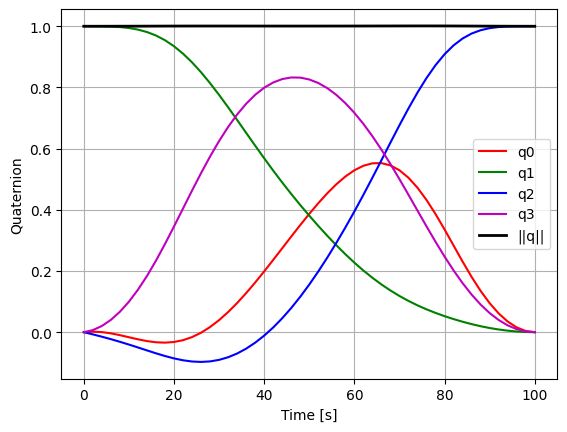

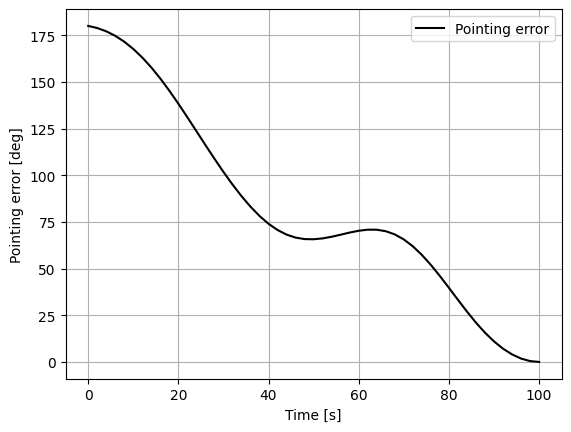

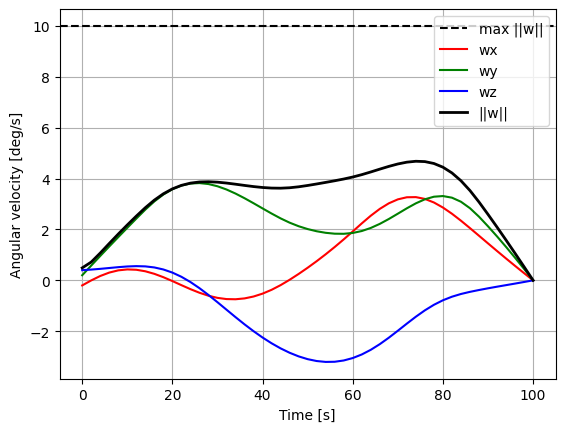

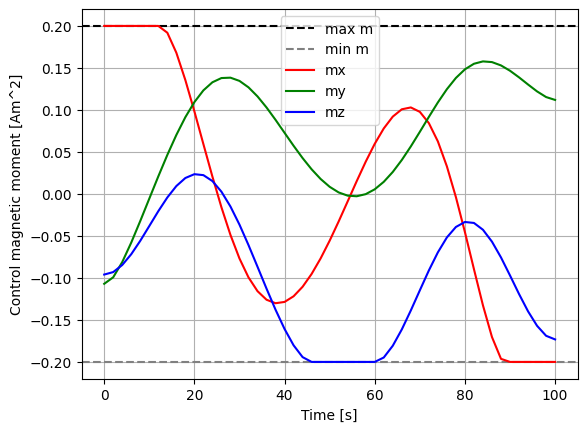

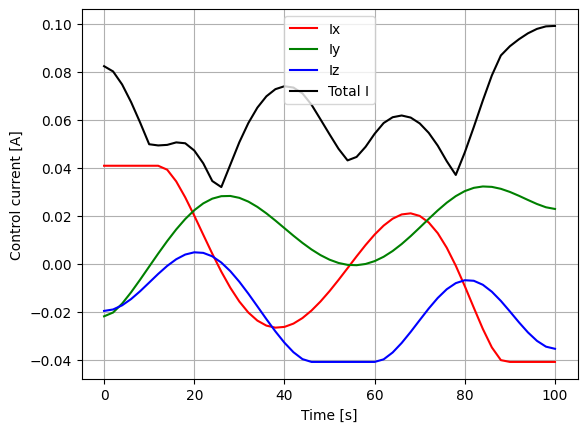

In [29]:
# Plot (scaled initial trajectories)
def global_inv_scaling(x,S,c,T):
    for i in range(0,T,1):
        x[:,i:i+1]=S@x[:,i:i+1]+c
    return x
#x_value = np.copy(x_global)
#u_value = np.copy(u_global)
x_value=global_inv_scaling(np.copy(ox),S_x_scaling_double,c_x_scaling_double,T+1)
u_value=global_inv_scaling(np.copy(ou),S_u_scaling_double,c_u_scaling_double,T+1)

for i in range(0,T+1):
    x_value[4:7,i:i+1] = np.linalg.inv(Jsat_double)@x_value[4:7,i:i+1]*180/np.pi

t1 = np.linspace(0, tf, T+1)
t2 = np.linspace(0, tf, T)

# --- Quaternion ---
plt.figure(1)
for i,c in zip(range(4),['r','g','b','m']):
    plt.plot(t1, x_value[i,:], c, label=f'q{i}')
plt.plot(t1, np.linalg.norm(x_value[0:4,:],axis=0), 'k', lw=2, label='||q||')
plt.grid(); plt.legend(); plt.xlabel('Time [s]');plt.ylabel('Quaternion')

# --- Pointing error ---
plt.figure(2)

rot_RN = R.from_quat(end_quat.T)
RN = rot_RN.as_matrix()
point_error = np.zeros((1,T+1))

for i in range(0,T+1):
    rot_BN = R.from_quat(x_value[0:4,i])
    BN = rot_BN.as_matrix()
    BR = BN@RN.T
    point_error[0,i] = math.acos(BR[2,2])

plt.plot(t1, point_error[0,:]*180/np.pi, 'k', label='Pointing error')
plt.grid(); plt.legend(); plt.xlabel('Time [s]');plt.ylabel('Pointing error [deg]')


# --- Angular velocity ---
plt.figure(4)
plt.axhline( omega_max_double*180/np.pi, c='k', ls='--', label='max ||w||')
for i,c,l in zip(range(4,7),['r','g','b'],['wx','wy','wz']):
    plt.plot(t1, x_value[i,:], c, label=l)
plt.plot(t1, np.linalg.norm(x_value[4:7,:],axis=0), 'k', lw=2, label='||w||')
plt.grid(); plt.legend(); plt.xlabel('Time [s]'); plt.ylabel('Angular velocity [deg/s]')

# --- Magnetic moment ---
plt.figure(6)
plt.axhline( m_max_double, c='k', ls='--', label='max m')
plt.axhline(-m_max_double, c='gray', ls='--', label='min m')
for i,c,l in zip(range(3),['r','g','b'],['mx','my','mz']):
    plt.plot(t1, u_value[i,:], c, label=l)
plt.grid(); plt.legend(); plt.xlabel('Time [s]');plt.ylabel('Control magnetic moment [Am^2]')

plt.show()

# --- Current ---
n_turns = 1000
A = 0.07*0.07

plt.figure(6)

for i,c,l in zip(range(3),['r','g','b'],['Ix','Iy','Iz']):
    plt.plot(t1, u_value[i,:]/(n_turns*A), c, label=l)
plt.plot(t1, np.sum(np.abs(u_value[:,:]/(n_turns*A)),axis = 0), 'k', label="Total I")
plt.grid(); plt.legend(); plt.xlabel('Time [s]');plt.ylabel('Control current [A]')

plt.show()

# CVXpygen (Waskiri-Sat)

In [535]:
from cvxpygen import cpg
cpg.generate_code(problem, code_dir='WaskiriSat_SCVX_ECOS_T51_l2_dm_FOH_opt',solver='ECOS')

Generating code with CVXPYgen ...
CVXPYgen finished generating code.
Compiling python wrapper with CVXPYgen ... 


c:\Users\franklin\anaconda3\envs\cvxpygen\lib\site-packages\setuptools\__init__.py:92: _DeprecatedInstaller: setuptools.installer and fetch_build_eggs are deprecated.
!!

        ********************************************************************************
        Requirements should be satisfied by a PEP 517 installer.
        If you are using pip, you can try `pip install --use-pep517`.

        This deprecation is overdue, please update your project and remove deprecated
        calls to avoid build errors in the future.
        ********************************************************************************

!!
  dist.fetch_build_eggs(dist.setup_requires)


CVXPYgen finished compiling python wrapper.
-- Selecting Windows SDK version 10.0.26100.0 to target Windows 10.0.26200.
-- The C compiler identification is MSVC 19.44.35219.0
-- The CXX compiler identification is MSVC 19.44.35219.0
-- Detecting C compiler ABI info
-- Detecting C compiler ABI info - done
-- Check for working C compiler: C:/Program Files/Microsoft Visual Studio/2022/Community/VC/Tools/MSVC/14.44.35207/bin/Hostx64/x64/cl.exe - skipped
-- Detecting C compile features
-- Detecting C compile features - done
-- Detecting CXX compiler ABI info
-- Detecting CXX compiler ABI info - done
-- Check for working CXX compiler: C:/Program Files/Microsoft Visual Studio/2022/Community/VC/Tools/MSVC/14.44.35207/bin/Hostx64/x64/cl.exe - skipped
-- Detecting CXX compile features
-- Detecting CXX compile features - done
-- Configuring done (5.2s)
-- Generating done (0.1s)
-- Build files have been written to: C:/Users/franklin/Documents/Kyutech/githubs/github_COGU/COGU_algorithms/Waskiri-Sat/

In [536]:
from WaskiriSat_SCVX_ECOS_T51_l2_dm_FOH_opt.cpg_solver import cpg_solve #CHANGE
import numpy as np
import pickle
import time
import matplotlib.pyplot as plt

with open('WaskiriSat_SCVX_ECOS_T51_l2_dm_FOH_opt/problem.pickle', 'rb') as file: #CHANGE
    problem = pickle.load(file)

problem.register_solve('cpg', cpg_solve)

In [537]:
ox = np.zeros((states_size, T+1)) 
ou = np.zeros((inputs_size, T+1))

etta_double = np.copy(etta_double_init)

inv_S_x_scaling_double = np.linalg.inv(S_x_scaling_double)
inv_S_u_scaling_double = np.linalg.inv(S_u_scaling_double)

ohx = np.copy(ohx_init) 
ohu = np.copy(ohu_init)

for t in range(0, T + 1):
    ox[0:states_size, t:t+1] = SCVx_scaling_x(
        ohx[0:states_size, t:t+1],
        inv_S_x_scaling_double,
        c_x_scaling_double
    )

for t in range(0, T + 1):
    ou[0:inputs_size, t:t+1] = SCVx_scaling_u(
        ohu[0:inputs_size, t:t+1],
        inv_S_u_scaling_double,
        c_u_scaling_double
    )

problem.param_dict['ox_cvxpy'].value = ox
problem.param_dict['ou_cvxpy'].value = ou

#problem.param_dict['tau'].value = tau_double
problem.param_dict['sqrt_tau'].value = tau_double**0.5
problem.param_dict['sqrt_alpha_m_sqrt_tau'].value = (alpha_m_double**0.5) * (tau_double**0.5)
#problem.param_dict['lamb'].value = lamb_double

problem.param_dict['tau_lamb'].value = tau_double * lamb_double
problem.param_dict['etta'].value = etta_double

#problem.param_dict['S_x_scaling'].value = S_x_scaling_double
problem.param_dict['S_u_scaling'].value = S_u_scaling_double

#problem.param_dict['c_x_scaling'].value = c_x_scaling_double
problem.param_dict['c_u_scaling'].value = c_u_scaling_double

problem.param_dict['omega_max'].value = omega_max_double
problem.param_dict['m_max'].value = m_max_double

problem.param_dict['start_pos'].value = SCVx_scaling_x(
    start_pos_double,
    inv_S_x_scaling_double,
    c_x_scaling_double
)

problem.param_dict['end_pos'].value = SCVx_scaling_x(
    end_pos_double,
    inv_S_x_scaling_double,
    c_x_scaling_double
)

aux_end_pos_double = SCVx_scaling_x(
    end_pos_double,
    inv_S_x_scaling_double,
    c_x_scaling_double
)

xq_goal_double = np.copy(aux_end_pos_double[0:4, 0:1])

problem.param_dict['inv_Jb_S_b_scaling'].value = (
    np.linalg.inv(Jsat_double) @ S_x_scaling_double[4:7, 4:7]
)

problem.param_dict['inv_Jb_c_b_scaling'].value = (
    np.linalg.inv(Jsat_double) @ c_x_scaling_double[4:7, 0:1]
)

t0 = time.time()

i = 1
no_first_iterations = False
rho_i = "None"

for COGU_iter in range(COGU_max_iter):

    for t in range(0, T + 1):
        ohx[0:states_size, t:t+1] = SCVx_inv_scaling_x(
            ox[0:states_size, t:t+1],
            S_x_scaling_double,
            c_x_scaling_double
        )

    for t in range(0, T + 1):
        ohu[0:inputs_size, t:t+1] = SCVx_inv_scaling_u(
            ou[0:inputs_size, t:t+1],
            S_u_scaling_double,
            c_u_scaling_double
        )

    t0aux = time.time()

    for k in range(0, T):
        A_k, B_l_k, B_r_k, y_k = A_Bl_Br_y_discrete_scaled(
            ohx[:, k:k+1],
            ohu[:, k:k+1],
            k/T*tf,
            dynamic_parameters_double,
            tau_double,
            S_x_scaling_double,
            inv_S_x_scaling_double,
            c_x_scaling_double,
            S_u_scaling_double,
            inv_S_u_scaling_double,
            c_u_scaling_double,
            size_N
        )

        aux_A_discrete[:, states_size*k:states_size*(k+1)] = A_k
        aux_B_discrete_l[:, inputs_size*k:inputs_size*(k+1)] = B_l_k
        aux_B_discrete_r[:, inputs_size*k:inputs_size*(k+1)] = B_r_k
        aux_y_discrete[:, k:k+1] = y_k

    if non_convex_inequalities_size > 0:
        for k in range(0, T+1):
            C_k, D_k, z_k = C_D_z_discrete_scaled(
                ohx[:, k:k+1],
                ohu[:, k:k+1],
                k/T*tf,
                dynamic_parameters_double,
                S_x_scaling_double,
                c_x_scaling_double,
                S_u_scaling_double,
                c_u_scaling_double
            )

            aux_C_discrete[:, states_size*k:states_size*(k+1)] = C_k
            aux_D_discrete[:, inputs_size*k:inputs_size*(k+1)] = D_k
            aux_z_discrete[:, k:k+1] = z_k

    t1aux = time.time()
    print("Discretization time [ms]: ", (t1aux - t0aux)*1000)

    problem.param_dict['A_discrete'].value = aux_A_discrete
    problem.param_dict['B_discrete_l'].value = aux_B_discrete_l
    problem.param_dict['B_discrete_r'].value = aux_B_discrete_r
    problem.param_dict['y_discrete'].value = aux_y_discrete

    if non_convex_inequalities_size > 0:
        problem.param_dict['C_discrete'].value = aux_C_discrete
        problem.param_dict['D_discrete'].value = aux_D_discrete
        problem.param_dict['z_discrete'].value = aux_z_discrete

    t0aux = time.time()
    val = problem.solve(method='cpg')
    print("Solver time [ms]: ", (time.time() - t0aux)*1000)

    vc_opt = np.copy(problem.var_dict['vc'].value)
    if non_convex_inequalities_size > 0:
        vi_opt = np.copy(problem.var_dict['vi'].value)

    x_opt = np.copy(problem.var_dict['x'].value)
    u_opt = np.copy(problem.var_dict['u'].value)

    oJ_SCVx = J_SCVx(
        ox, ou, T, tau_double, dynamic_parameters_double,
        xq_goal_double, S_x_scaling_double, c_x_scaling_double,
        S_u_scaling_double, c_u_scaling_double
    )

    J_SCVx_opt = J_SCVx(
        x_opt, u_opt, T, tau_double, dynamic_parameters_double,
        xq_goal_double, S_x_scaling_double, c_x_scaling_double,
        S_u_scaling_double, c_u_scaling_double
    )

    print("Iteration number: ",i," Etta: ",problem.param_dict['etta'].value, " Rho: ",rho_i)
    print("L_SCVx_opt: "+str(val)+" J_SCVx_opt: "+str(J_SCVx_opt)+" oJ_SCVx: "+str(oJ_SCVx)+" Norm_x_diff: "+str(np.max(np.linalg.norm((x_opt-ox), ord=2,axis=0))),"\n")

    Delta_J_SCVx = oJ_SCVx - J_SCVx_opt
    Delta_L_SCVx = oJ_SCVx - val

    if (
        (Delta_L_SCVx < e_tol*np.abs(oJ_SCVx)
         or np.max(np.linalg.norm(x_opt-ox, axis=0)) < epsilon_stop_norm)
        and no_first_iterations
    ):
        print("COGU has converged! :)")
        break
    else:
      rho_i=Delta_J_SCVx/Delta_L_SCVx
      if rho_i<rho0:
        problem.param_dict['etta'].value=max([etta0,problem.param_dict['etta'].value/beta_sh])
        ox=np.copy(ox)
        ou=np.copy(ou)
      if rho_i>=rho0 and rho_i<rho1:
        problem.param_dict['etta'].value=max([etta0,problem.param_dict['etta'].value/beta_sh])
        ox=np.copy(x_opt)
        ou=np.copy(u_opt)
      if rho_i>=rho1 and rho_i<rho2:
        ox=np.copy(x_opt)
        ou=np.copy(u_opt)
      if rho_i>=rho2:
        problem.param_dict['etta'].value=min([etta1,beta_gr*problem.param_dict['etta'].value])
        ox=np.copy(x_opt)
        ou=np.copy(u_opt)

    problem.param_dict['ox_cvxpy'].value = ox
    problem.param_dict['ou_cvxpy'].value = ou

    if i == 3:
        no_first_iterations = True

    i += 1

t1 = time.time()
print('\nCVXPY\nSolve time: %.3f ms' % (1000 * (t1 - t0)))

Discretization time [ms]:  683.260440826416
Solver time [ms]:  27.180910110473633
Cost:  49.99999999999999
Cost + vc:  79400.40543742725
Cost:  56.23524708345619
Cost + vc:  13548.351618250372
Iteration number:  1  Etta:  1.0  Rho:  None
L_SCVx_opt: 56.23524702500791 J_SCVx_opt: 13548.351618250372 oJ_SCVx: 79400.40543742725 Norm_x_diff: 0.2870252713591271 

Discretization time [ms]:  766.8390274047852
Solver time [ms]:  32.00531005859375
Cost:  56.23524708345619
Cost + vc:  13548.351618250372
Cost:  18.653256005713256
Cost + vc:  1596.4522039167632
Iteration number:  2  Etta:  2.0  Rho:  0.8299545342922067
L_SCVx_opt: 18.65325811760064 J_SCVx_opt: 1596.4522039167632 oJ_SCVx: 13548.351618250372 Norm_x_diff: 0.12604333492103706 

Discretization time [ms]:  712.4459743499756
Solver time [ms]:  32.00244903564453
Cost:  18.653256005713256
Cost + vc:  1596.4522039167632
Cost:  21.865576046094894
Cost + vc:  100.03173365371057
Iteration number:  3  Etta:  4.0  Rho:  0.8833825482430283
L_SCVx_

In [538]:
print("vc error (quaternion):")
print(np.linalg.norm((problem.var_dict['vc'].value[0:4, :]), ord=1))

print("vc error (ang. velocity):")
print(np.linalg.norm((problem.var_dict['vc'].value[4:7, :]), ord=1))

vc error (quaternion):
8.395695581251093e-08
vc error (ang. velocity):
0.0008103199034389663


C:\Users\franklin\AppData\Local\Temp\ipykernel_15272\4004544860.py:35: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  point_error[0,i] = math.acos(BR[2,2])


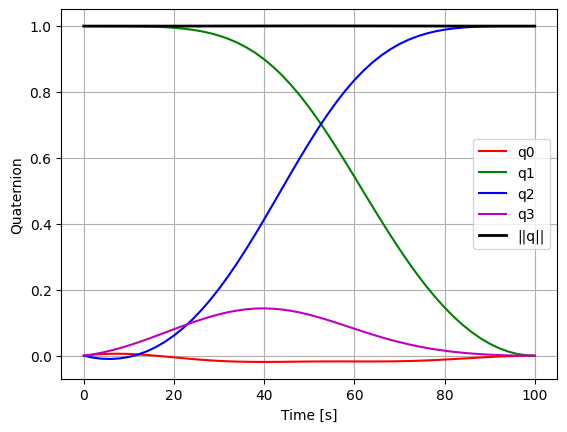

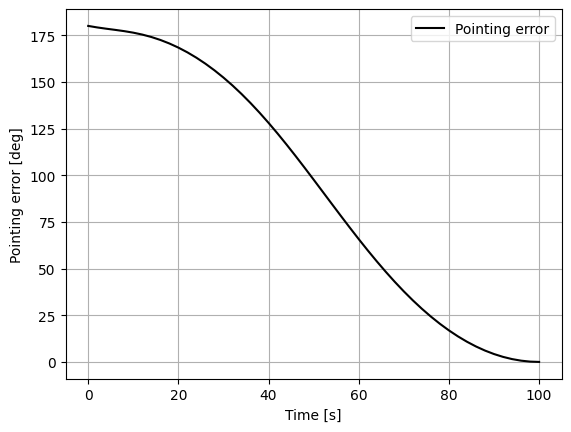

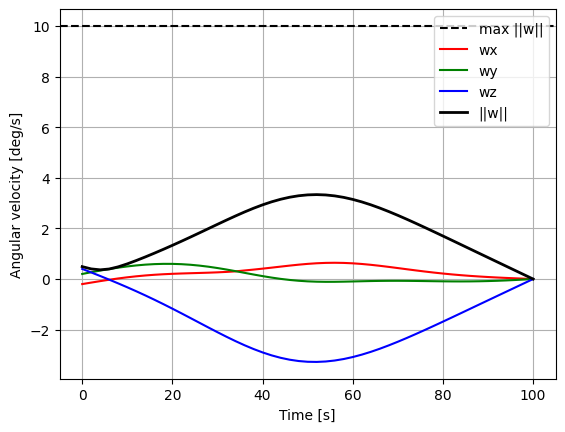

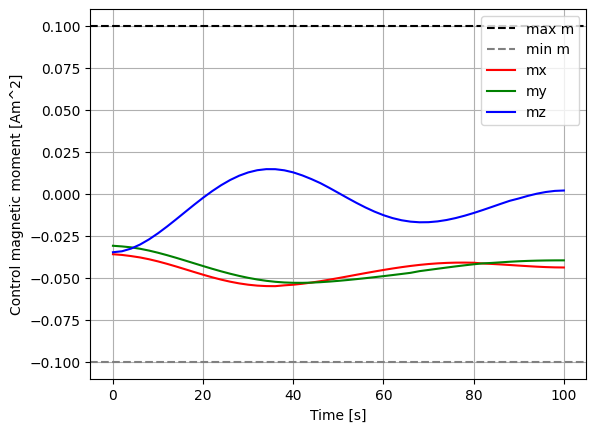

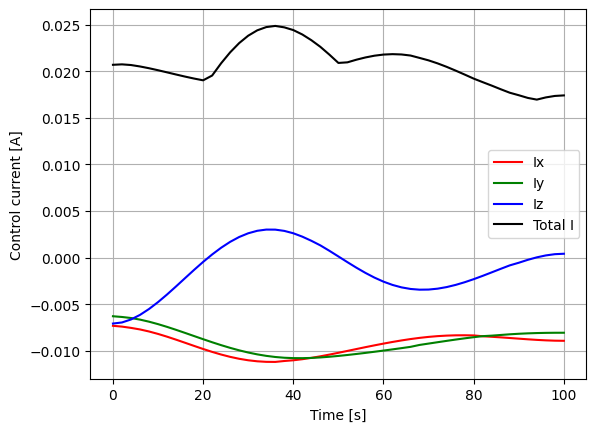

In [539]:
# Plot (scaled initial trajectories)
def global_inv_scaling(x,S,c,T):
    for i in range(0,T,1):
        x[:,i:i+1]=S@x[:,i:i+1]+c
    return x
#x_value = np.copy(x_global)
#u_value = np.copy(u_global)
x_value=global_inv_scaling(np.copy(ox),S_x_scaling_double,c_x_scaling_double,T+1)
u_value=global_inv_scaling(np.copy(ou),S_u_scaling_double,c_u_scaling_double,T+1)

for i in range(0,T+1):
    x_value[4:7,i:i+1] = np.linalg.inv(Jsat_double)@x_value[4:7,i:i+1]*180/np.pi

t1 = np.linspace(0, tf, T+1)
t2 = np.linspace(0, tf, T)

# --- Quaternion ---
plt.figure(1)
for i,c in zip(range(4),['r','g','b','m']):
    plt.plot(t1, x_value[i,:], c, label=f'q{i}')
plt.plot(t1, np.linalg.norm(x_value[0:4,:],axis=0), 'k', lw=2, label='||q||')
plt.grid(); plt.legend(); plt.xlabel('Time [s]');plt.ylabel('Quaternion')

# --- Pointing error ---
plt.figure(2)

rot_RN = R.from_quat(end_quat.T)
RN = rot_RN.as_matrix()
point_error = np.zeros((1,T+1))

for i in range(0,T+1):
    rot_BN = R.from_quat(x_value[0:4,i])
    BN = rot_BN.as_matrix()
    BR = BN@RN.T
    point_error[0,i] = math.acos(BR[2,2])

plt.plot(t1, point_error[0,:]*180/np.pi, 'k', label='Pointing error')
plt.grid(); plt.legend(); plt.xlabel('Time [s]');plt.ylabel('Pointing error [deg]')


# --- Angular velocity ---
plt.figure(4)
plt.axhline( omega_max_double*180/np.pi, c='k', ls='--', label='max ||w||')
for i,c,l in zip(range(4,7),['r','g','b'],['wx','wy','wz']):
    plt.plot(t1, x_value[i,:], c, label=l)
plt.plot(t1, np.linalg.norm(x_value[4:7,:],axis=0), 'k', lw=2, label='||w||')
plt.grid(); plt.legend(); plt.xlabel('Time [s]'); plt.ylabel('Angular velocity [deg/s]')

# --- Magnetic moment ---
plt.figure(6)
plt.axhline( m_max_double, c='k', ls='--', label='max m')
plt.axhline(-m_max_double, c='gray', ls='--', label='min m')
for i,c,l in zip(range(3),['r','g','b'],['mx','my','mz']):
    plt.plot(t1, u_value[i,:], c, label=l)
plt.grid(); plt.legend(); plt.xlabel('Time [s]');plt.ylabel('Control magnetic moment [Am^2]')

plt.show()

# --- Current ---
n_turns = 1000
A = 0.07*0.07

plt.figure(6)

for i,c,l in zip(range(3),['r','g','b'],['Ix','Iy','Iz']):
    plt.plot(t1, u_value[i,:]/(n_turns*A), c, label=l)
plt.plot(t1, np.sum(np.abs(u_value[:,:]/(n_turns*A)),axis = 0), 'k', label="Total I")
plt.grid(); plt.legend(); plt.xlabel('Time [s]');plt.ylabel('Control current [A]')

plt.show()

# Open loop simulation

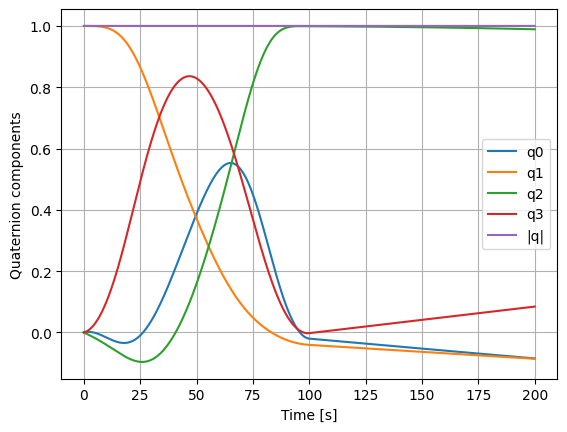

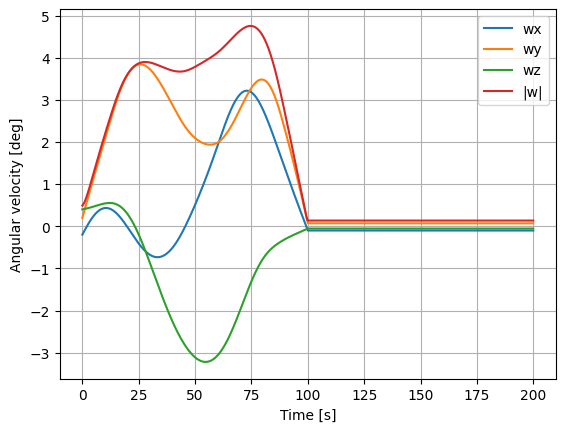

C:\Users\franklin\AppData\Local\Temp\ipykernel_37192\3101113544.py:240: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  point_error[0,i] = math.acos(BR[2,2])


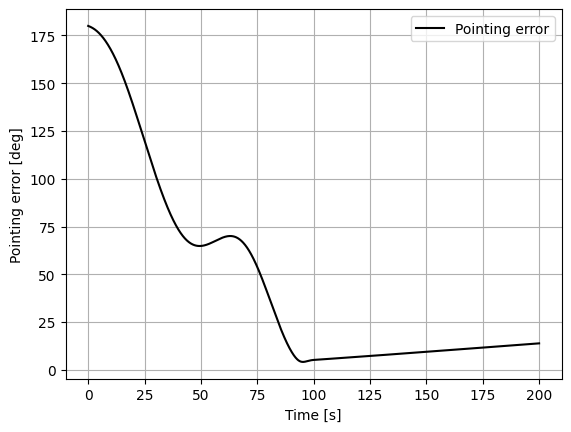

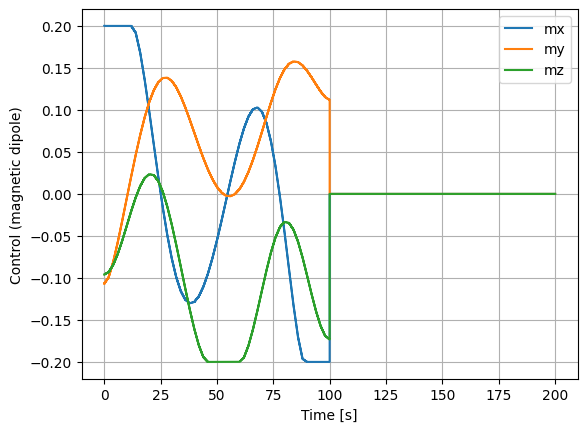

In [30]:
import numpy as np
import matplotlib.pyplot as plt

def u_interpol_zoh(t, u_value, dt_control):
    """
    Zero-order hold interpolation
    u_value: shape (3, T_control)
    dt_control: paso de discretización del control
    """

    T_control = u_value.shape[1]

    index = int(np.floor(t / dt_control))

    if index >= T_control:
        index = T_control - 1

    return u_value[:, index]

def u_interpol_linear(t, u_value, dt_control):
    """
    Linear interpolation of control input

    Parameters
    ----------
    t : float
        Current simulation time
    u_value : ndarray shape (3, T_control)
        Discrete control samples
    dt_control : float
        Control sampling time

    Returns
    -------
    u_interp : ndarray shape (3,)
        Interpolated control vector at time t
    """

    T_control = u_value.shape[1]

    # Índice inferior
    index = int(np.floor(t / dt_control))

    # Si estamos fuera del rango → mantener último valor
    if index >= T_control - 1:
        return np.array([0,0,0])

    # Tiempo local dentro del intervalo
    t0 = index * dt_control
    alpha = (t - t0) / dt_control  # 0 ≤ alpha < 1

    # Interpolación lineal
    u0 = u_value[:, index]
    u1 = u_value[:, index + 1]
    
    return (1 - alpha) * u0 + alpha * u1
    
def quat_to_dcm(q):
    q0, q1, q2, q3 = q
    return np.array([
        [q0**2 + q1**2 - q2**2 - q3**2, 2*(q1*q2 + q0*q3), 2*(-q0*q2 + q1*q3)],
        [2*(q1*q2 - q0*q3), q0**2 - q1**2 + q2**2 - q3**2, 2*(q0*q1 + q2*q3)],
        [2*(q0*q2 + q1*q3), 2*(-q0*q1 + q2*q3), q0**2 - q1**2 - q2**2 + q3**2]
    ])

def dcm_ZXZ(Omega, inc, theta):
    cO = np.cos(Omega)
    sO = np.sin(Omega)
    ci = np.cos(inc)
    si = np.sin(inc)
    ct = np.cos(theta)
    st = np.sin(theta)

    Rz1 = np.array([[cO, -sO, 0],
                    [sO,  cO, 0],
                    [0,   0,  1]])

    Rx  = np.array([[1, 0, 0],
                    [0, ci, -si],
                    [0, si,  ci]])

    Rz2 = np.array([[ct, -st, 0],
                    [st,  ct, 0],
                    [0,   0,  1]])

    return (Rz1 @ Rx @ Rz2).T


# =============================
# Dinámica
# =============================

def dynamics(t, x, u, params):

    q = x[0:4]
    w = x[4:7]
    m = u

    I = params["I"]
    I_inv = params["I_inv"]
    n = params["n"]
    Omega = params["Omega"]
    inc = params["inc"]
    B0 = params["B0"]
    t0_double = params["t0"]

    O_B = np.array([
        -2*np.sin(inc)*np.cos(n*(t+t0_double)),
        -np.sin(inc)*np.sin(n*(t+t0_double)),
         np.cos(inc)
    ]) * B0

    BN = quat_to_dcm(q)
    ON = dcm_ZXZ(Omega, inc, n*(t+t0_double))
    BO = BN @ ON.T

    torque = np.cross(m, BO @ O_B)

    w_dot = I_inv @ (-np.cross(w, I @ w) + torque)

    q0, q1, q2, q3 = q
    wx, wy, wz = w

    q_dot = 0.5 * np.array([
        -wx*q1 - wy*q2 - wz*q3,
         wx*q0 + wz*q2 - wy*q3,
         wy*q0 - wz*q1 + wx*q3,
         wz*q0 + wy*q1 - wx*q2
    ])

    return np.concatenate((q_dot, w_dot))


# =============================
# RK4
# =============================

def rk4_step(f, t, x, u, dt, params):

    k1 = f(t, x, u, params)
    k2 = f(t + dt/2, x + dt/2 * k1, u, params)
    k3 = f(t + dt/2, x + dt/2 * k2, u, params)
    k4 = f(t + dt, x + dt * k3, u, params)

    x_next = x + dt/6 * (k1 + 2*k2 + 2*k3 + k4)

    # Normalizar cuaternión
    #x_next[0:4] /= np.linalg.norm(x_next[0:4])

    return x_next


# =============================
# Simulación
# =============================

inertia_error = 0*0.00001 
I = np.array([[Jsat_double[0,0]+inertia_error,Jsat_double[0,1],Jsat_double[0,2]+inertia_error],
              [Jsat_double[1,0],Jsat_double[1,1]-inertia_error,Jsat_double[2,1]],
              [Jsat_double[2,0]+inertia_error,Jsat_double[2,1],Jsat_double[2,2]]])

params = {
    "I": I,
    "I_inv": np.linalg.inv(I),
    "n": n_cubesat_double,
    "Omega": Omega_double,
    "inc": inc_double,
    "B0": B0_double,
    "t0": t0_double
}

x = np.array([start_quat[0,0], start_quat[1,0], start_quat[2,0], start_quat[3,0], start_w_xyz[0,0], start_w_xyz[1,0], start_w_xyz[2,0]])

dt_state = 0.05 # step RK4 (closed loop)
dt_control = tau_double  # COGU control each tau_double [s]
N = int((tf+100)/dt_state)+1

q_history = np.zeros((N, 4))
w_history = np.zeros((N, 3))
t_history = np.zeros(N)
u_history = np.zeros((N, 3))
t=0

for i in range(N):
    q_history[i] = x[0:4]
    w_history[i] = x[4:7]
    t_history[i] = t

    #u_current = u_interpol_zoh(t, u_value, dt_control)
    u_current = u_interpol_linear(t, u_value, dt_control)
    
    u_history[i] = u_current   # <-- guardar control

    x = rk4_step(dynamics, t, x, u_current, dt_state, params)
    t += dt_state


# =============================
# Plot quaternion
# =============================

plt.figure(1)
plt.plot(t_history, q_history[:, 0])
plt.plot(t_history, q_history[:, 1])
plt.plot(t_history, q_history[:, 2])
plt.plot(t_history, q_history[:, 3])
plt.plot(t_history, np.linalg.norm(q_history,ord=2,axis=1))
plt.xlabel("Time [s]")
plt.ylabel("Quaternion components")
plt.legend(["q0", "q1", "q2", "q3", "|q|"])
plt.grid(True)
plt.show()

# =============================
# Plot angular velocity
# =============================

plt.figure(1)
plt.plot(t_history, w_history[:, 0]*180/np.pi)
plt.plot(t_history, w_history[:, 1]*180/np.pi)
plt.plot(t_history, w_history[:, 2]*180/np.pi)
plt.plot(t_history, np.linalg.norm(w_history,ord=2,axis=1)*180/np.pi)
plt.xlabel("Time [s]")
plt.ylabel("Angular velocity [deg]")
plt.legend(["wx", "wy", "wz", "|w|"])
plt.grid(True)
plt.show()

# --- Pointing error ---
plt.figure(2)

rot_RN = R.from_quat(end_quat.T)
RN = rot_RN.as_matrix()
point_error = np.zeros((1,N))

for i in range(N):
    rot_BN = R.from_quat(q_history[i, :])
    BN = rot_BN.as_matrix()
    BR = BN@RN.T
    point_error[0,i] = math.acos(BR[2,2])

plt.plot(t_history, point_error[0,:]*180/np.pi, 'k', label='Pointing error')
plt.grid(); plt.legend(); plt.xlabel('Time [s]');plt.ylabel('Pointing error [deg]')

plt.figure()
plt.step(t_history, u_history[:, 0])
plt.step(t_history, u_history[:, 1])
plt.step(t_history, u_history[:, 2])
plt.xlabel("Time [s]")
plt.ylabel("Control (magnetic dipole)")
plt.legend(["mx", "my", "mz"])
plt.grid(True)
plt.show()